# CORRELATION ANALYSIS
I need to narrow down the variables in the analysis statistically and logically. I have many that are NA's I would like to remove them if possible. I will try to make a few different datasets that have different limitations. 

### Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn import datasets
from sklearn import cluster
import sklearn
import seaborn as sns
from sklearn import decomposition
from sklearn import metrics
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn import svm
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from scipy.stats import boxcox
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# allow us to see all columns
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("../Datasets_P1/df_Cost.csv")
df.sample(5)

C:\Users\lukep\AppData\Local\Temp\ipykernel_11532\3932104159.py:1: DtypeWarning: Columns (8,90) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../Datasets_P1/df_Cost.csv")


,rpt_rec_num,Provider_CCN,Facility_Name,Street_Address,City,State_Code,Zip_Code,County,Medicare_CBSA_Number,Rural_versus_Urban,Fiscal_Year_Begin_Date,Fiscal_Year_End_Date,Type_of_Control,Accounts_Receivable,Accounts_payable,Buildings,Cash_on_hand_and_in_banks,General_fund_balance,Gross_Revenue,Inpatient_PPS_Amount,Inpatient_Revenue,Less_Total_Operating_Expense,Less_discounts_on_patients,Major_movable_equipment,Net_Income,Net_Patient_Revenue,Number_of_Beds,Other_Assets,Other_current_liabilities,Overhead_Non_Salary_Costs,SNF_Admissions_Other,SNF_Admissions_Title_XIX,SNF_Admissions_Title_XVIII,SNF_Admissions_Total,SNF_Days_Other,SNF_Days_Title_XIX,SNF_Days_Title_XVIII,SNF_Days_Total,SNF_Discharges_Title_Other,SNF_Discharges_Title_XIX,SNF_Discharges_Title_XVIII,SNF_Discharges_Total,Salaries_wages_and_fees_payable,Total_Assets,Total_Bed_Days_Available,Total_Costs,Total_Days_Other,Total_Days_Title_XIX,Total_Days_Title_XVIII,Total_Days_Total,Total_Discharges_Title_Other,Total_Discharges_Title_XIX,Total_Discharges_Title_XVIII,Total_Discharges_Total,Total_Income,Total_RUG_Days,Total_Salaries_From_Worksheet_A,Total_current_liabilities,Total_fixed_Assets,Total_fund_balances,Total_liabilities,Total_other_Assets,Fixed_equipment,Total_Charges,Contract_Labor,SNF_Number_of_Beds,Less:_Allowances_for_uncollectible_notes_and_accounts_receivable,Total_long_term_liabilities,Investments,Net_Income_from_service_to_patients,Wage-related_Costs_(core),Total_Salaries_(adjusted),SNF_Average_Length_of_Stay_Total,Notes_Payable,Other_long_term_liabilities,Payroll_taxes_payable,Land_improvements,Allowable_Bad_Debts,SNF_Average_Length_of_Stay_Title_XVIII,Total_General_Inpatient_Care_Services_Revenue,Total_Liabilities_and_fund_balances,SNF_Average_Length_of_Stay_Title_XIX,Other_current_assets,Total_Current_Assets,Total_Other_Income,Outpatient_Revenue,SNF_Bed_Days_Available,Leasehold_improvements,Mortgage_payable,Notes_and_Loans_Payable_(short_term),Land,Inventory,Prepaid_expenses,Year
77253,1284219,235252,LOURDES NURSING HOME,2300 WATKINS LAKE ROAD,WATERFORD,MI,48328,OAKLAND,47664.0,U,01/01/2020,12/31/2020,1.0,1085153.0,4022917.0,15485251.0,1127143.0,7915429.0,16381629.0,2882397.0,16381629.0,11416842.0,5291390.0,1201660.0,1315831.0,11090239.0,100.0,NaN,NaN,5500746.0,194.0,7.0,261.0,462.0,5033.0,18917.0,5102.0,29052.0,192.0,49.0,226.0,467.0,205468.0,25778726.0,36600.0,1398626.0,5033.0,18917.0,5102.0,29052.0,192.0,49.0,226.0,467.0,1399716.0,NaN,5916096.0,6429695.0,21866283.0,7915429.0,17863297.0,1955448.0,1264848.0,5730909.0,784799.0,100.0,294368.0,11433602.0,1955448.0,-326603.0,855604.0,5916096.0,62.21,NaN,NaN,472474.0,242174.0,NaN,22.58,10651721.0,25778726.0,386.06,-126125.0,1956995.0,1726319.0,0.0,36600.0,NaN,11433602.0,NaN,3716000.0,NaN,136238.0,2020
91755,1313453,105637,MARIANNA HEALTH & REHAB CENTER,4295 5TH AVENUE,MARIANNA,FL,32446,JACKSON,99910.0,R,10/01/2020,09/30/2021,8.0,2522957.0,867863.0,9541222.0,1446338.0,-609273.0,12261370.0,2538708.0,12261370.0,14223317.0,-99705.0,NaN,-1240067.0,12361075.0,180.0,2444349.0,533925.0,8019580.0,30.0,23.0,85.0,138.0,1822.0,36042.0,5133.0,42997.0,23.0,25.0,75.0,123.0,704450.0,10427031.0,65700.0,1519101.0,1822.0,36042.0,5133.0,42997.0,23.0,25.0,75.0,123.0,-1240067.0,NaN,6203737.0,2111789.0,5320401.0,-609273.0,11036304.0,2445117.0,3339876.0,1983244.0,63337.0,180.0,1367983.0,8924515.0,NaN,-1862242.0,2471797.0,6203737.0,349.57,NaN,8924515.0,5551.0,NaN,338292.0,68.44,10278126.0,10427031.0,1441.68,NaN,2661513.0,622175.0,0.0,65700.0,NaN,NaN,NaN,50000.0,109451.0,30327.0,2021
16978,1163834,185146,4021 FOUNTAIN CIRCLE CARE & REHABILI,200 GLENWAY RD,WINCHESTER,KY,40391,CLARK,30460.0,U,1/1/2016,12/31/2016,4.0,2866121.0,425511.0,NaN,-90200.0,763836.0,15911021.0,2477283.0,15911021.0,13437629.0,3099355.0,234507.0,-624529.0,12811666.0,179.0,222731.0,NaN,7676775.0,226.0,47.0,103.0,376.0,7400.0,37379.0,4765.0,49544.0,204.0,76.0,97.0,377.0,277276.0,2830372.0,65514.0,2189307.0,7400.0,37379.0,4765.0,49544.0,204.0,76.0,97.0,377.0,-624529.0

In [4]:
# Count the total number of columns in df
num_columns = df.shape[1]

# Display the count
print(f"Total number of variables in df: {num_columns}")

Total number of variables in df: 94


C:\Users\lukep\AppData\Local\Temp\ipykernel_11532\3148070167.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_filled[col].fillna(df_filled[col].median(), inplace=True)
C:\Users\lukep\AppData\Local\Temp\ipykernel_11532\3148070167.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

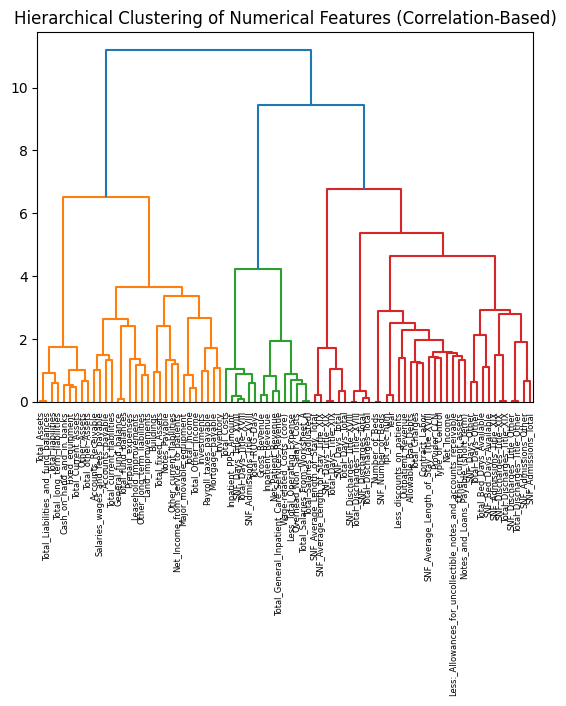

Correlation-Based Feature Clusters: {'Cluster 1': ['Cash_on_hand_and_in_banks', 'Other_Assets', 'Total_Assets', 'Total_liabilities', 'Total_other_Assets', 'Fixed_equipment', 'Total_long_term_liabilities', 'Total_Liabilities_and_fund_balances', 'Total_Current_Assets'], 'Cluster 2': ['Accounts_Receivable', 'Accounts_payable', 'Salaries_wages_and_fees_payable', 'Total_current_liabilities'], 'Cluster 3': ['General_fund_balance', 'Total_fund_balances', 'Other_long_term_liabilities', 'Land_improvements', 'Leasehold_improvements', 'Prepaid_expenses'], 'Cluster 4': ['Buildings', 'Other_current_liabilities', 'Total_fixed_Assets', 'Net_Income_from_service_to_patients', 'Notes_Payable'], 'Cluster 5': ['Major_movable_equipment', 'Total_Income', 'Total_Other_Income'], 'Cluster 6': ['Investments', 'Payroll_taxes_payable', 'Mortgage_payable', 'Inventory'], 'Cluster 7': ['Inpatient_PPS_Amount', 'SNF_Admissions_Title_XVIII', 'SNF_Days_Title_XVIII', 'Total_Costs', 'Total_Days_Title_XVIII', 'Total_RUG_Da

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.preprocessing import LabelEncoder

# Ensure target column exists
target = "Net_Income"
if target not in df.columns:
    raise ValueError(f"Target variable '{target}' not found in the dataset.")

# Handling missing values: Fill NAs with median (for numerical) or mode (for categorical)
df_filled = df.copy()
for col in df_filled.columns:
    if df_filled[col].dtype == 'object':
        df_filled[col].fillna(df_filled[col].mode()[0], inplace=True)
    else:
        df_filled[col].fillna(df_filled[col].median(), inplace=True)

# Separate numerical and categorical columns
num_cols = df_filled.select_dtypes(include=[np.number]).columns
cat_cols = df_filled.select_dtypes(include=['object']).columns

### 1. Correlation-Based Clustering ###
# Compute correlation matrix
corr_matrix = df_filled[num_cols].corr()

# Apply hierarchical clustering
linkage_matrix = linkage(1 - np.abs(corr_matrix), method='ward')
dendrogram(linkage_matrix, labels=num_cols, leaf_rotation=90)
plt.title("Hierarchical Clustering of Numerical Features (Correlation-Based)")
plt.show()

# Assign clusters (tune 't' for granularity)
clusters = fcluster(linkage_matrix, t=2.5, criterion='distance')
clustered_features = {f'Cluster {c}': [] for c in np.unique(clusters)}
for col, cluster in zip(num_cols, clusters):
    clustered_features[f'Cluster {cluster}'].append(col)

print("Correlation-Based Feature Clusters:", clustered_features)


In [6]:
# remove this bc it is the same as another column
df = df.drop(columns=['Total_Salaries_From_Worksheet_A'])

# FIRST Dataset
I will heavily remove NA filled variables especially if they are correlated to another variable that has higher correlation with the target

So I will be seperating the dataset by groups that I think are relevant to each other and that I know have lots of NAs based on previous analysis

In [7]:
# Select columns that contain the word 'assets' and also include 'Net_Income'
assets_cols = [col for col in df.columns if 'assets' in col.lower()]
assets_cols.append('Net_Income')  # Add 'Net_Income' to the list

# Create a new DataFrame with only the selected columns
group = df[assets_cols]

# Display the selected columns

group.head()


,Other_Assets,Total_Assets,Total_fixed_Assets,Total_other_Assets,Other_current_assets,Total_Current_Assets,Net_Income
0,NaN,765020.0,55061.0,-729268.0,NaN,1439227.0,311430.0
1,36000.0,1687456.0,671306.0,36000.0,NaN,980150.0,-588469.0
2,NaN,244239.0,NaN,NaN,NaN,244239.0,-47859.0
3,NaN,1830758.0,26949.0,74985.0,NaN,1728824.0,-63638.0
4,NaN,807209.0,NaN,NaN,NaN,807209.0,-1613.0


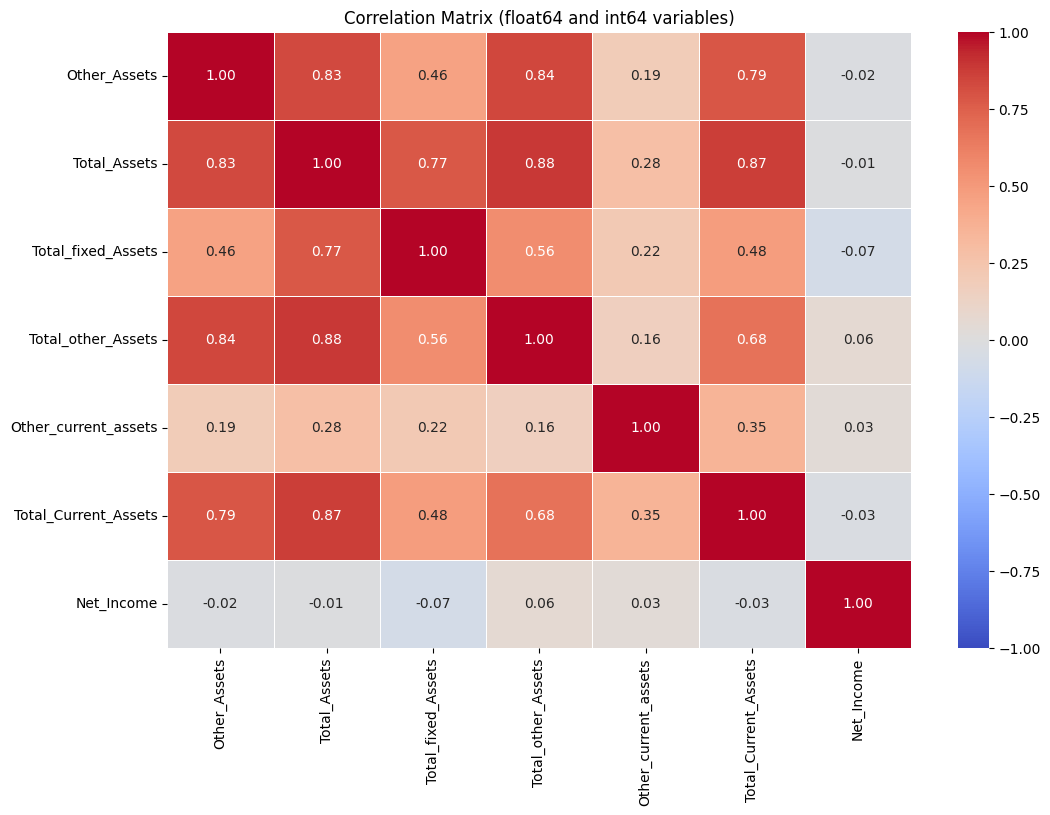

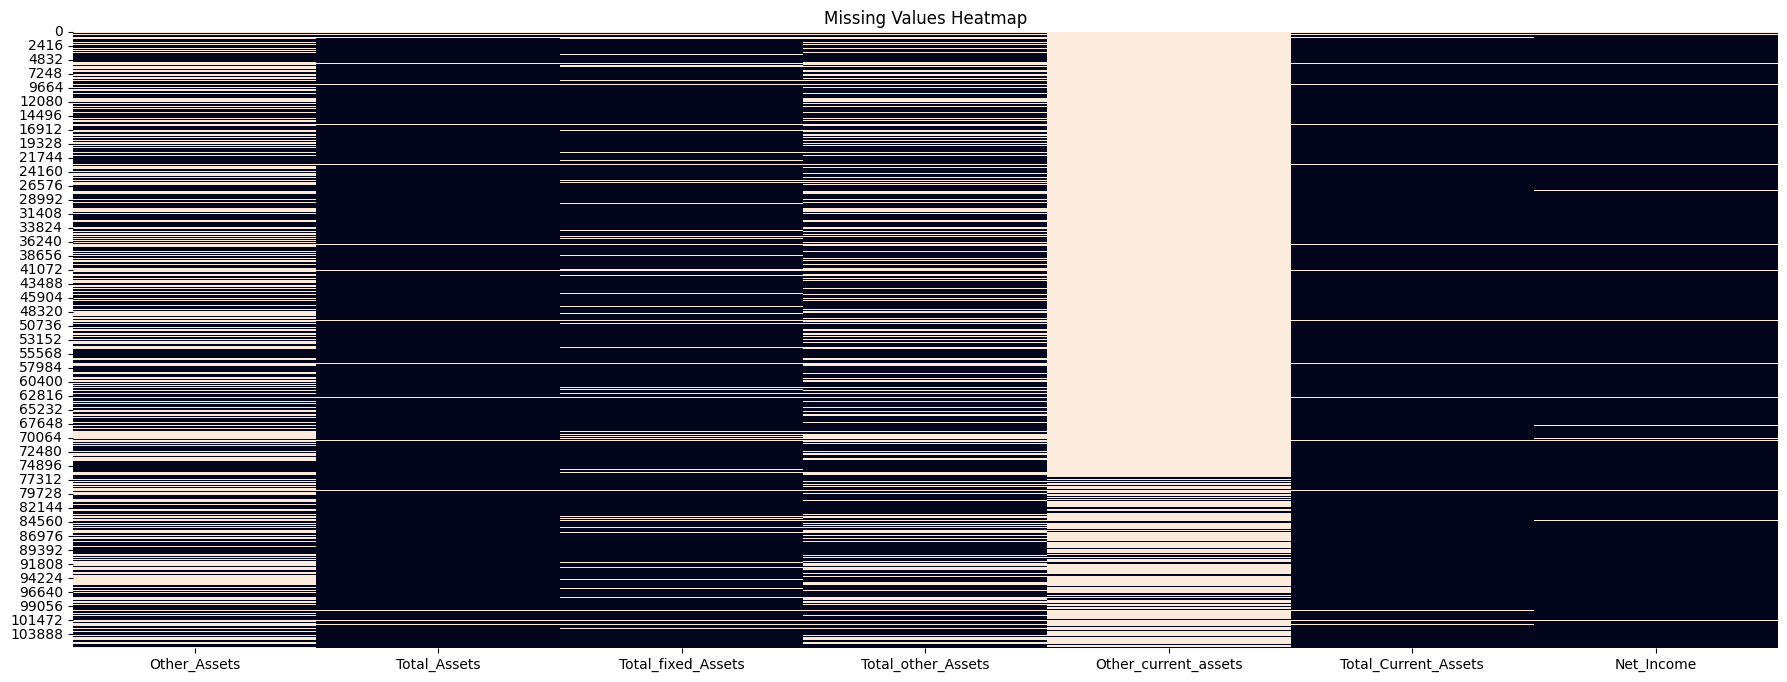

In [8]:
# Select numerical columns (float64 and int64)
num_cols = group.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix for the selected columns
corr_matrix = group[num_cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix (float64 and int64 variables)")
plt.show()

# Plot the missing values heatmap
plt.figure(figsize=(22, 8))
sns.heatmap(group.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


DROP the useless datasets

In [9]:
# Calculate percentage of missing values for each column
missing_percentage = group.isnull().mean() * 100

# Get the columns with more than 50% missing values
cols_to_check = missing_percentage[missing_percentage > 50].index

# Compute the correlation matrix for numerical columns
corr_matrix = group.select_dtypes(include=['float64', 'int64']).corr()

# Get the correlation of each column with 'Net_Income'
correlation_with_net_income = corr_matrix['Net_Income'].sort_values(ascending=False)

# Identify columns to drop
columns_to_drop = []
for col in cols_to_check:
    # Check if any other column has a higher correlation with Net_Income
    if correlation_with_net_income[col] < correlation_with_net_income.iloc[0]:  # Compare with the highest correlation
        columns_to_drop.append(col)

# Drop the identified columns from the dataset
group_cleaned = df.drop(columns=columns_to_drop)

# Print the columns that were dropped
print(f"Columns dropped due to >50% NA and lower correlation with Net_Income: {columns_to_drop}")

# Optionally, display the cleaned dataset
# print(group_cleaned.head())


Columns dropped due to >50% NA and lower correlation with Net_Income: ['Other_current_assets']


### Another one

In [10]:
# Select columns that contain the word 'assets' and also include 'Net_Income'
assets_cols = [col for col in df.columns if 'liabilities' in col.lower()]
assets_cols.append('Net_Income')  # Add 'Net_Income' to the list

# Create a new DataFrame with only the selected columns
group = df[assets_cols]

# Display the selected columns

group.head()

,Other_current_liabilities,Total_current_liabilities,Total_liabilities,Total_long_term_liabilities,Other_long_term_liabilities,Total_Liabilities_and_fund_balances,Net_Income
0,5667.0,453591.0,453590.0,-1.0,NaN,765020.0,311430.0
1,2596536.0,2765768.0,6584403.0,3818635.0,NaN,1687456.0,-588469.0
2,25982.0,192098.0,192098.0,0.0,NaN,244239.0,-47859.0
3,97267.0,1824376.0,1824376.0,0.0,NaN,1830758.0,-63638.0
4,50688.0,808822.0,808822.0,0.0,NaN,807209.0,-1613.0


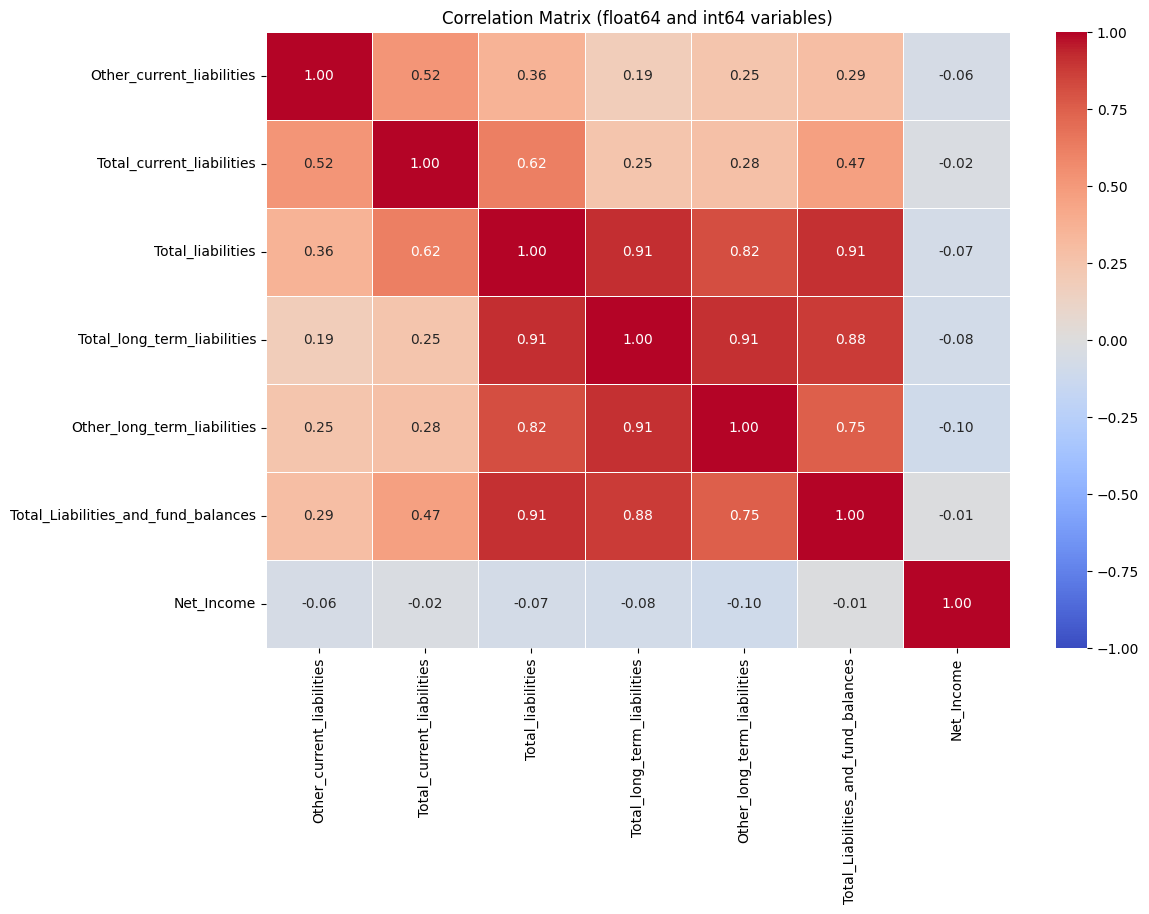

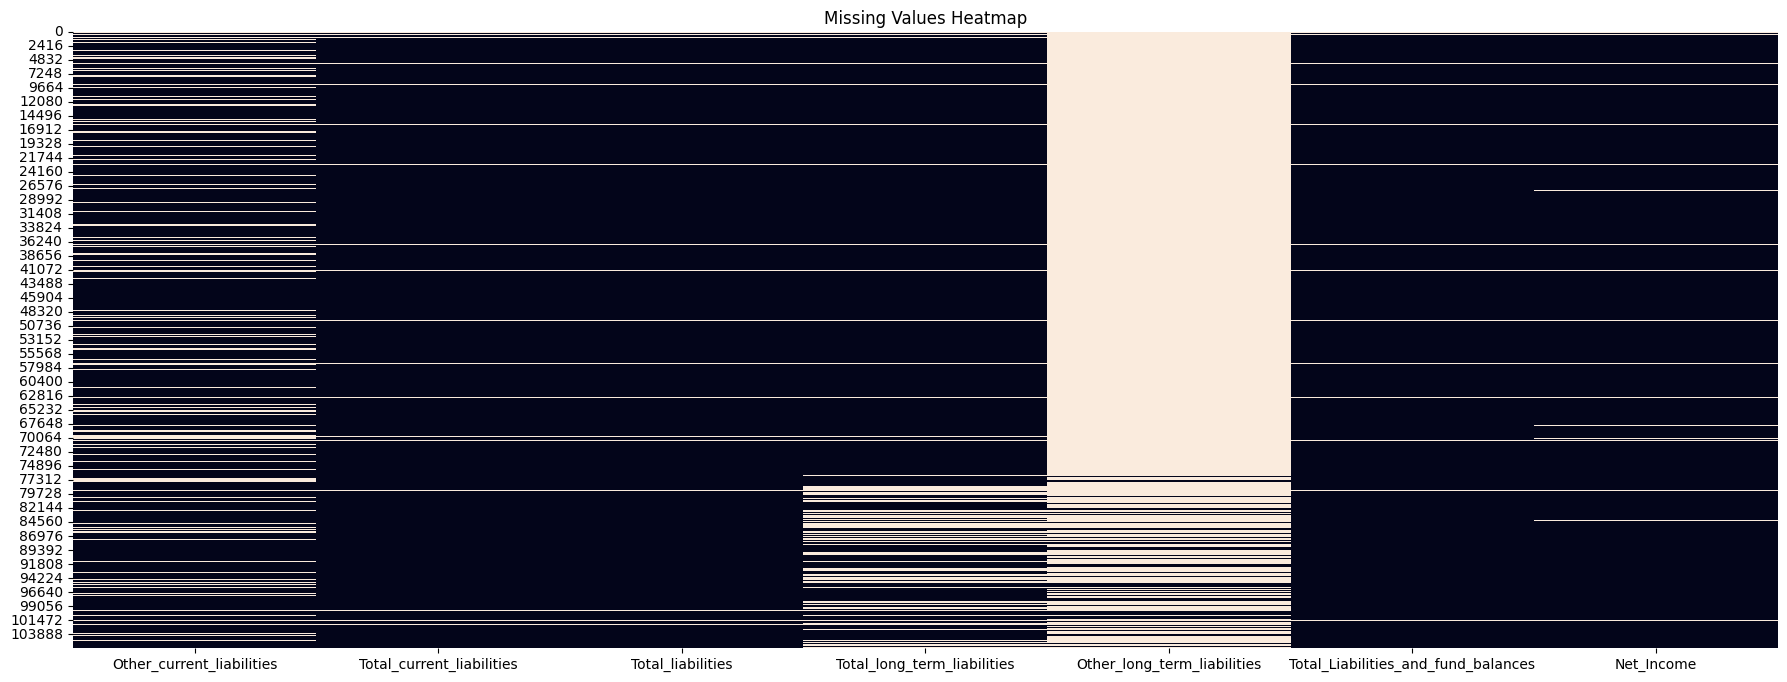

In [11]:
# Select numerical columns (float64 and int64)
num_cols = group.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix for the selected columns
corr_matrix = group[num_cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix (float64 and int64 variables)")
plt.show()

# Plot the missing values heatmap
plt.figure(figsize=(22, 8))
sns.heatmap(group.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [12]:
# Calculate percentage of missing values for each column
missing_percentage = group.isnull().mean() * 100

# Get the columns with more than 50% missing values
cols_to_check = missing_percentage[missing_percentage > 50].index

# Compute the correlation matrix for numerical columns
corr_matrix = group.select_dtypes(include=['float64', 'int64']).corr()

# Get the correlation of each column with 'Net_Income', excluding 'Net_Income' itself
correlation_with_net_income = corr_matrix['Net_Income'].drop('Net_Income').sort_values(ascending=False)

# Convert correlations to absolute values to ensure we are comparing magnitudes, not the direction
absolute_corr_with_net_income = correlation_with_net_income.abs()

# Identify columns to drop
columns_to_drop = []
better_correlated_vars = []  # To store variables with better correlation

for col in cols_to_check:
    # Ensure that the column exists in absolute correlation data before comparing
    if col in absolute_corr_with_net_income:
        # Check if its absolute correlation with Net_Income is less than the highest absolute correlation
        if absolute_corr_with_net_income[col] < absolute_corr_with_net_income.iloc[0]:  # Compare with the highest correlation
            columns_to_drop.append(col)
            # List columns that have a better absolute correlation with Net_Income
            better_correlated_vars.extend(absolute_corr_with_net_income[absolute_corr_with_net_income > absolute_corr_with_net_income[col]].index)

# Drop the identified columns from the dataset
group_cleaned = group.drop(columns=columns_to_drop)

# Print the columns that were dropped
print(f"Columns dropped due to >50% NA and lower absolute correlation with Net_Income: {columns_to_drop}")

# List the variables that have a better correlation with Net_Income than the dropped ones
print("\nVariables with better absolute correlation with Net_Income:")
better_correlated_vars = list(set(better_correlated_vars))  # Remove duplicates
print(better_correlated_vars)

# Optionally, display the cleaned dataset
# print(group_cleaned.head())

# Print correlation values for review
print("\nAbsolute Correlation with Net_Income:")
print(absolute_corr_with_net_income)


Columns dropped due to >50% NA and lower absolute correlation with Net_Income: []

Variables with better absolute correlation with Net_Income:
[]

Absolute Correlation with Net_Income:
Total_Liabilities_and_fund_balances    0.011372
Total_current_liabilities              0.023809
Other_current_liabilities              0.055542
Total_liabilities                      0.074091
Total_long_term_liabilities            0.079302
Other_long_term_liabilities            0.097215
Name: Net_Income, dtype: float64


In [13]:
# Select columns that contain the word 'assets' and also include 'Net_Income'
assets_cols = [col for col in df.columns if 'payable' in col.lower()]
assets_cols.append('Net_Income')  # Add 'Net_Income' to the list

# Create a new DataFrame with only the selected columns
group = df[assets_cols]

# Display the selected columns

group.head()

,Accounts_payable,Salaries_wages_and_fees_payable,Notes_Payable,Payroll_taxes_payable,Mortgage_payable,Notes_and_Loans_Payable_(short_term),Net_Income
0,292277.0,117929.0,NaN,NaN,NaN,NaN,311430.0
1,NaN,12590.0,NaN,NaN,NaN,NaN,-588469.0
2,79894.0,48546.0,NaN,NaN,NaN,NaN,-47859.0
3,537451.0,201598.0,NaN,NaN,NaN,NaN,-63638.0
4,253637.0,258540.0,NaN,NaN,NaN,NaN,-1613.0


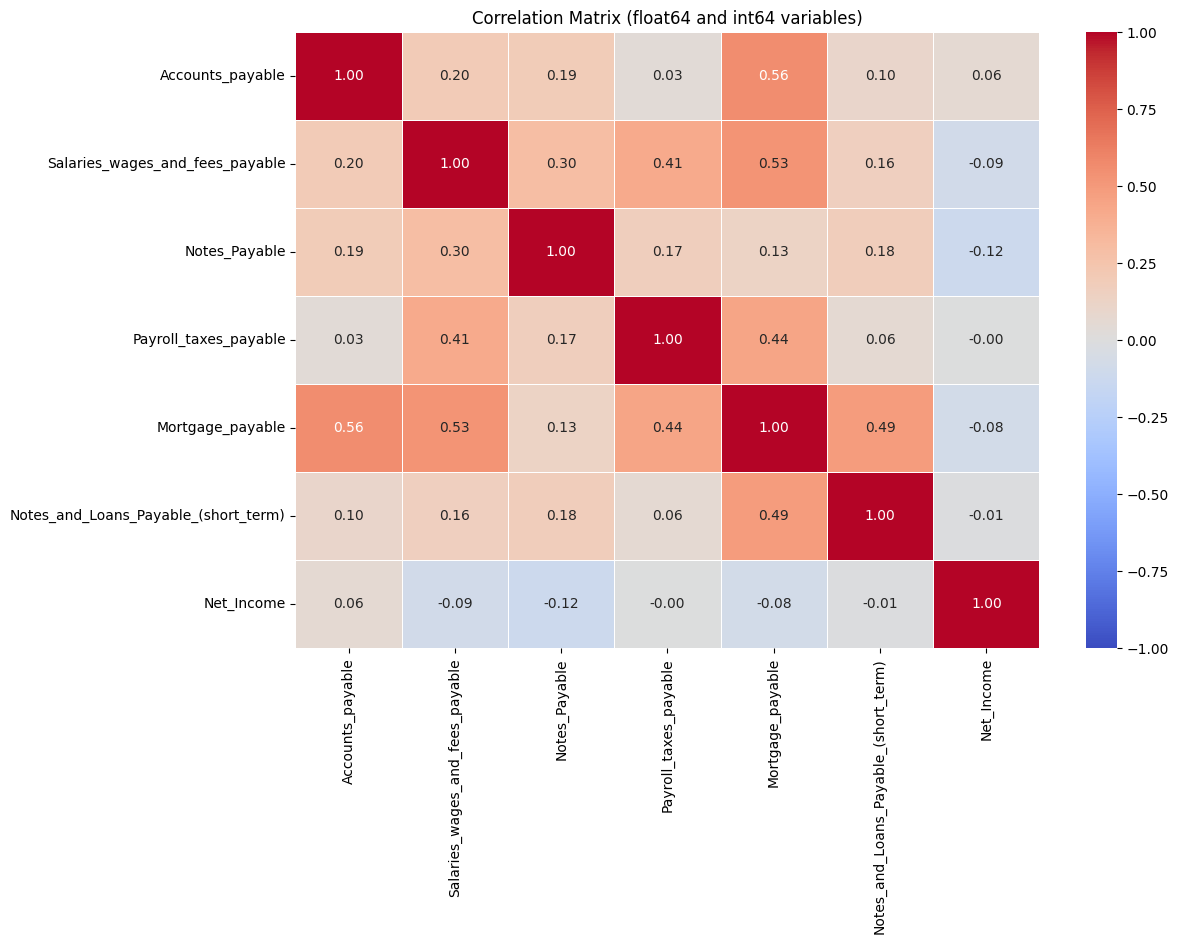

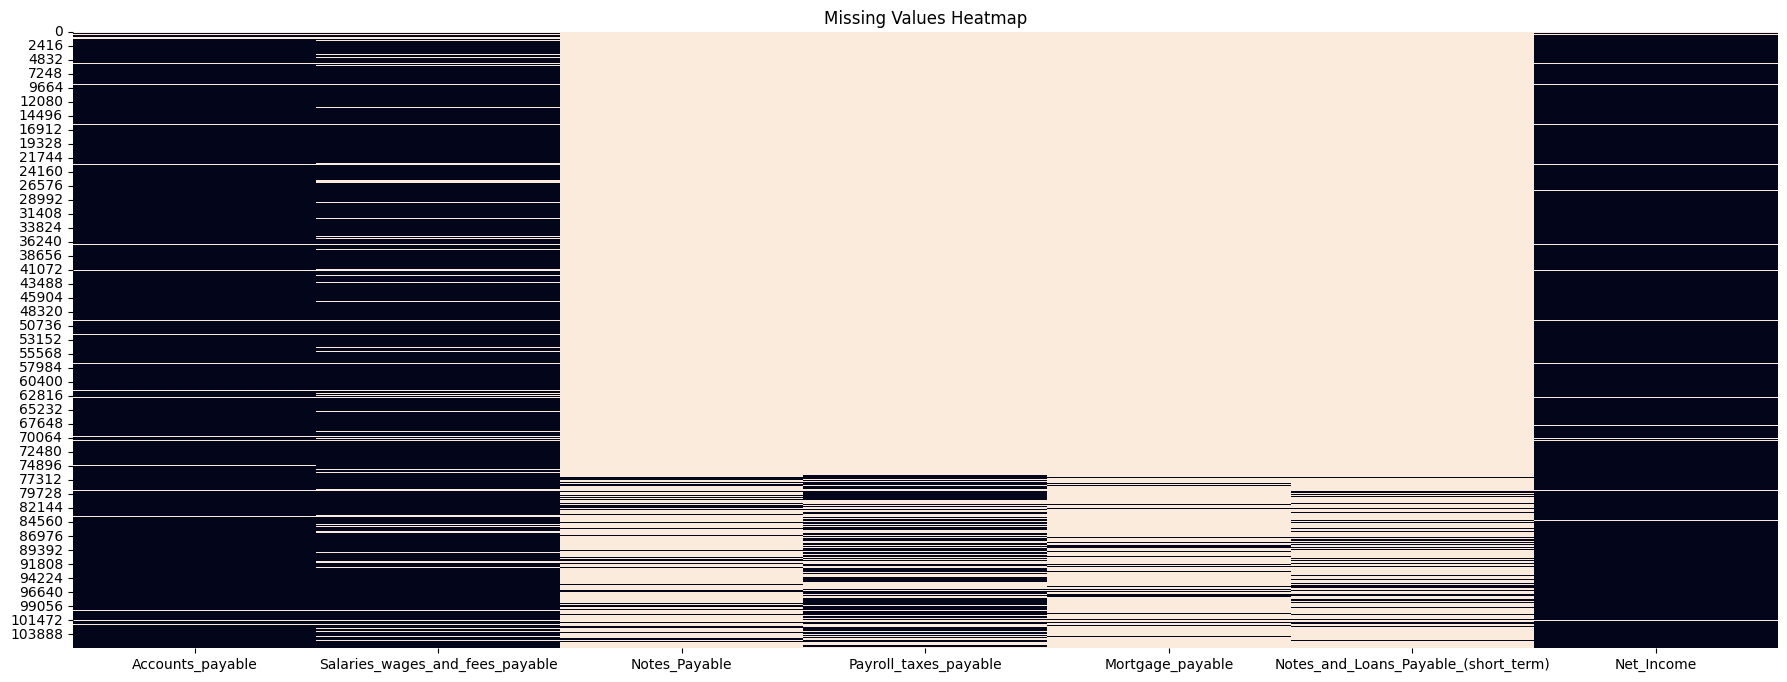

In [14]:
# Select numerical columns (float64 and int64)
num_cols = group.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix for the selected columns
corr_matrix = group[num_cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix (float64 and int64 variables)")
plt.show()

# Plot the missing values heatmap
plt.figure(figsize=(22, 8))
sns.heatmap(group.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [15]:
# Calculate percentage of missing values for each column
missing_percentage = group.isnull().mean() * 100

# Get the columns with more than 50% missing values
cols_to_check = missing_percentage[missing_percentage > 50].index

# Compute the correlation matrix for numerical columns
corr_matrix = group.select_dtypes(include=['float64', 'int64']).corr()

# Get the correlation of each column with 'Net_Income', excluding 'Net_Income' itself
correlation_with_net_income = corr_matrix['Net_Income'].drop('Net_Income').sort_values(ascending=False)

# Convert correlations to absolute values to ensure we are comparing magnitudes, not the direction
absolute_corr_with_net_income = correlation_with_net_income.abs()

# Identify the column with the highest absolute correlation
max_corr = absolute_corr_with_net_income.max()

# Identify columns to drop (those with less correlation than the maximum correlation)
columns_to_drop = []
for col in cols_to_check:
    # Ensure that the column exists in absolute correlation data before comparing
    if col in absolute_corr_with_net_income:
        if absolute_corr_with_net_income[col] < max_corr:  # Drop if its correlation is less than the max
            columns_to_drop.append(col)

# Drop the identified columns from the dataset
df = df.drop(columns=columns_to_drop)

# Print the columns that were dropped
print(f"Columns dropped due to >50% NA and lower absolute correlation with Net_Income: {columns_to_drop}")

# Optionally, display the cleaned dataset
# print(group_cleaned.head())

# Print correlation values for review
print("\nAbsolute Correlation with Net_Income:")
print(absolute_corr_with_net_income)


Columns dropped due to >50% NA and lower absolute correlation with Net_Income: ['Payroll_taxes_payable', 'Mortgage_payable', 'Notes_and_Loans_Payable_(short_term)']

Absolute Correlation with Net_Income:
Accounts_payable                        0.058095
Payroll_taxes_payable                   0.000806
Notes_and_Loans_Payable_(short_term)    0.010681
Mortgage_payable                        0.081361
Salaries_wages_and_fees_payable         0.091322
Notes_Payable                           0.121031
Name: Net_Income, dtype: float64


In [16]:
# Select columns that contain the word 'assets' and also include 'Net_Income'
assets_cols = [col for col in df.columns if 'charges' in col.lower()]
assets_cols.append('Net_Income')  # Add 'Net_Income' to the list

# Create a new DataFrame with only the selected columns
group = df[assets_cols]

# Display the selected columns

group.head()

,SNF_Discharges_Title_Other,SNF_Discharges_Title_XIX,SNF_Discharges_Title_XVIII,SNF_Discharges_Total,Total_Discharges_Title_Other,Total_Discharges_Title_XIX,Total_Discharges_Title_XVIII,Total_Discharges_Total,Total_Charges,Net_Income
0,9.0,35.0,5.0,49.0,9.0,35.0,5.0,49.0,NaN,311430.0
1,36.0,NaN,23.0,59.0,36.0,NaN,23.0,59.0,NaN,-588469.0
2,3.0,3.0,3.0,9.0,3.0,3.0,3.0,9.0,NaN,-47859.0
3,13.0,13.0,6.0,32.0,13.0,13.0,6.0,32.0,NaN,-63638.0
4,4.0,24.0,NaN,28.0,4.0,24.0,NaN,28.0,NaN,-1613.0


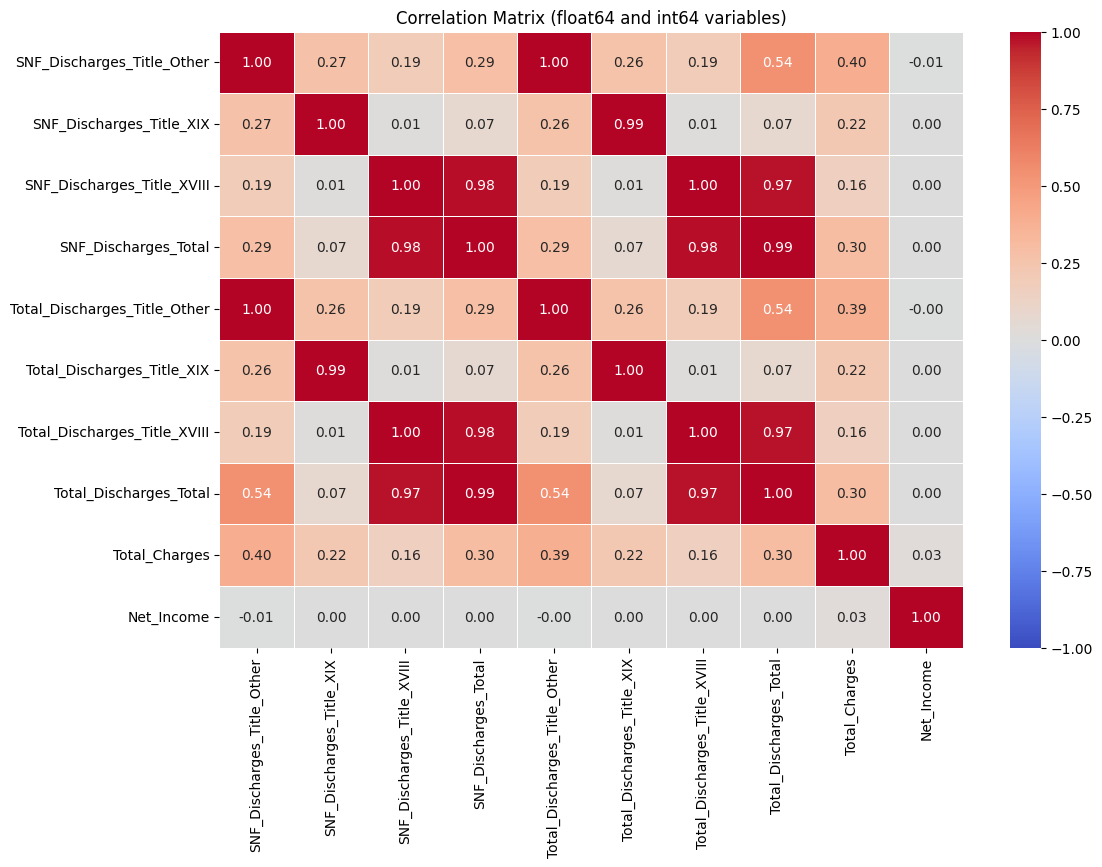

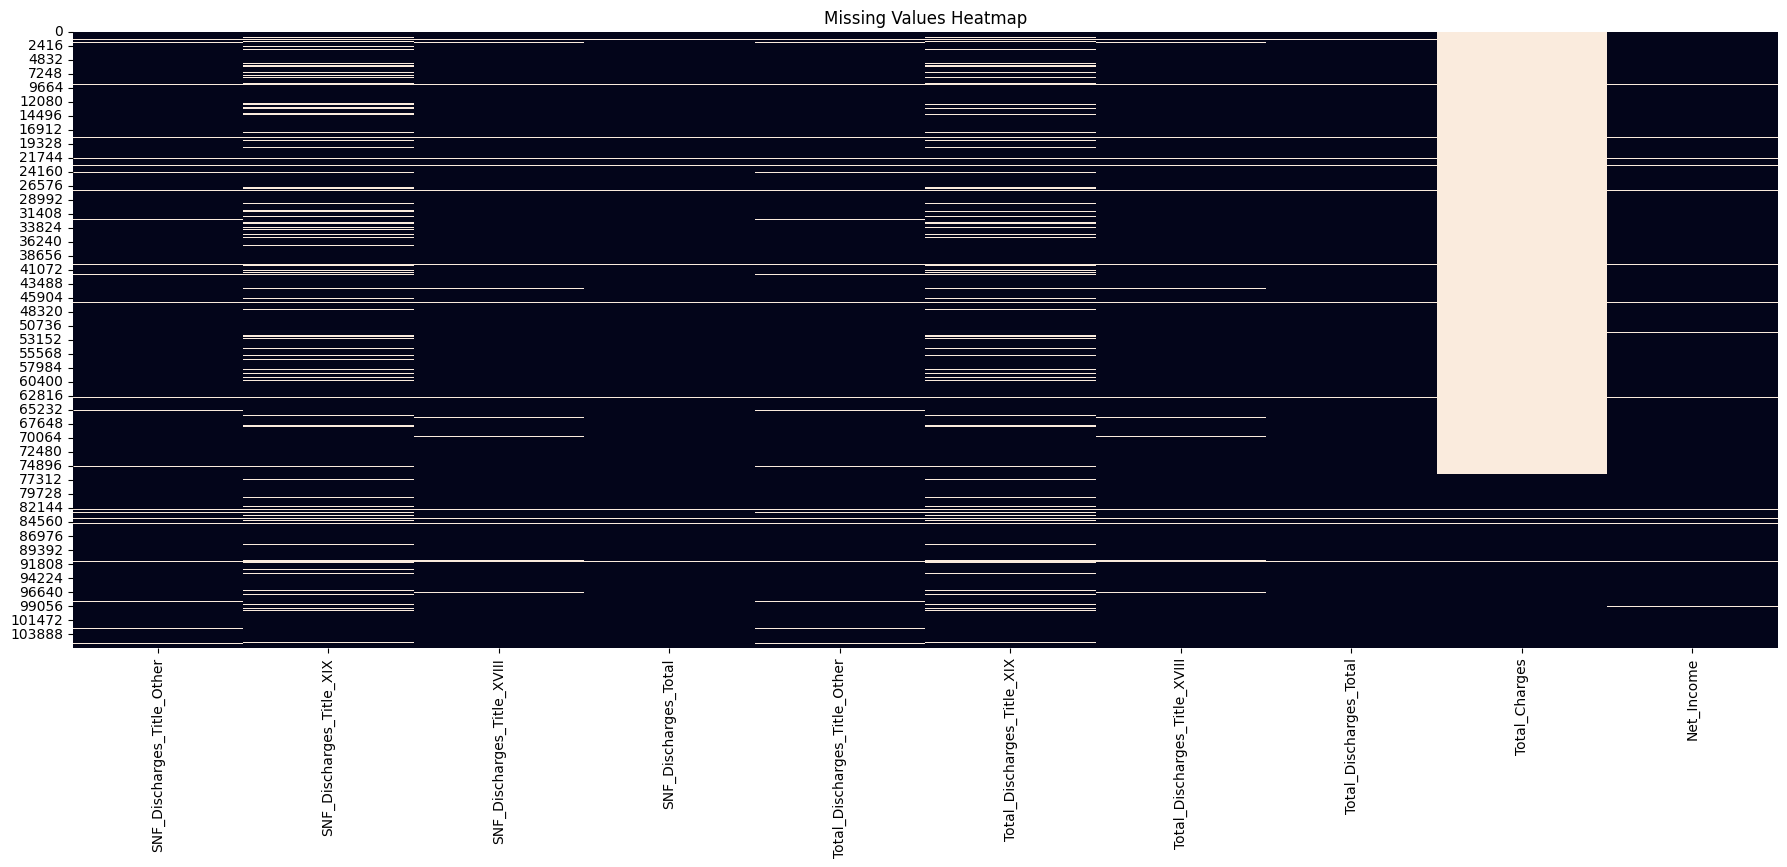

In [17]:
# Select numerical columns (float64 and int64)
num_cols = group.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix for the selected columns
corr_matrix = group[num_cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix (float64 and int64 variables)")
plt.show()

# Plot the missing values heatmap
plt.figure(figsize=(22, 8))
sns.heatmap(group.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [18]:
# Calculate percentage of missing values for each column
missing_percentage = group.isnull().mean() * 100

# Get the columns with more than 50% missing values
cols_to_check = missing_percentage[missing_percentage > 50].index

# Compute the correlation matrix for numerical columns
corr_matrix = group.select_dtypes(include=['float64', 'int64']).corr()

# Get the correlation of each column with 'Net_Income', excluding 'Net_Income' itself
correlation_with_net_income = corr_matrix['Net_Income'].drop('Net_Income').sort_values(ascending=False)

# Convert correlations to absolute values to ensure we are comparing magnitudes, not the direction
absolute_corr_with_net_income = correlation_with_net_income.abs()

# Identify columns to drop
columns_to_drop = []
better_correlated_vars = []  # To store variables with better correlation

for col in cols_to_check:
    # Ensure that the column exists in absolute correlation data before comparing
    if col in absolute_corr_with_net_income:
        # Check if its absolute correlation with Net_Income is less than the highest absolute correlation
        if absolute_corr_with_net_income[col] < absolute_corr_with_net_income.iloc[0]:  # Compare with the highest correlation
            columns_to_drop.append(col)
            # List columns that have a better absolute correlation with Net_Income
            better_correlated_vars.extend(absolute_corr_with_net_income[absolute_corr_with_net_income > absolute_corr_with_net_income[col]].index)

# Drop the identified columns from the dataset
group_cleaned = group.drop(columns=columns_to_drop)

# Print the columns that were dropped
print(f"Columns dropped due to >50% NA and lower absolute correlation with Net_Income: {columns_to_drop}")

# List the variables that have a better correlation with Net_Income than the dropped ones
print("\nVariables with better absolute correlation with Net_Income:")
better_correlated_vars = list(set(better_correlated_vars))  # Remove duplicates
print(better_correlated_vars)

# Optionally, display the cleaned dataset
# print(group_cleaned.head())

# Print correlation values for review
print("\nAbsolute Correlation with Net_Income:")
print(absolute_corr_with_net_income)


Columns dropped due to >50% NA and lower absolute correlation with Net_Income: []

Variables with better absolute correlation with Net_Income:
[]

Absolute Correlation with Net_Income:
Total_Charges                   0.026170
SNF_Discharges_Title_XIX        0.002130
Total_Discharges_Title_XIX      0.001652
Total_Discharges_Title_XVIII    0.001311
SNF_Discharges_Title_XVIII      0.001311
Total_Discharges_Total          0.000858
SNF_Discharges_Total            0.000740
Total_Discharges_Title_Other    0.004891
SNF_Discharges_Title_Other      0.005071
Name: Net_Income, dtype: float64


In [19]:
# Select columns that contain the word 'assets' and also include 'Net_Income'
assets_cols = [col for col in df.columns if 'labor' in col.lower()]
assets_cols.append('Net_Income')  # Add 'Net_Income' to the list

# Create a new DataFrame with only the selected columns
group = df[assets_cols]

# Display the selected columns

group.head()

,Contract_Labor,Net_Income
0,NaN,311430.0
1,NaN,-588469.0
2,NaN,-47859.0
3,NaN,-63638.0
4,NaN,-1613.0


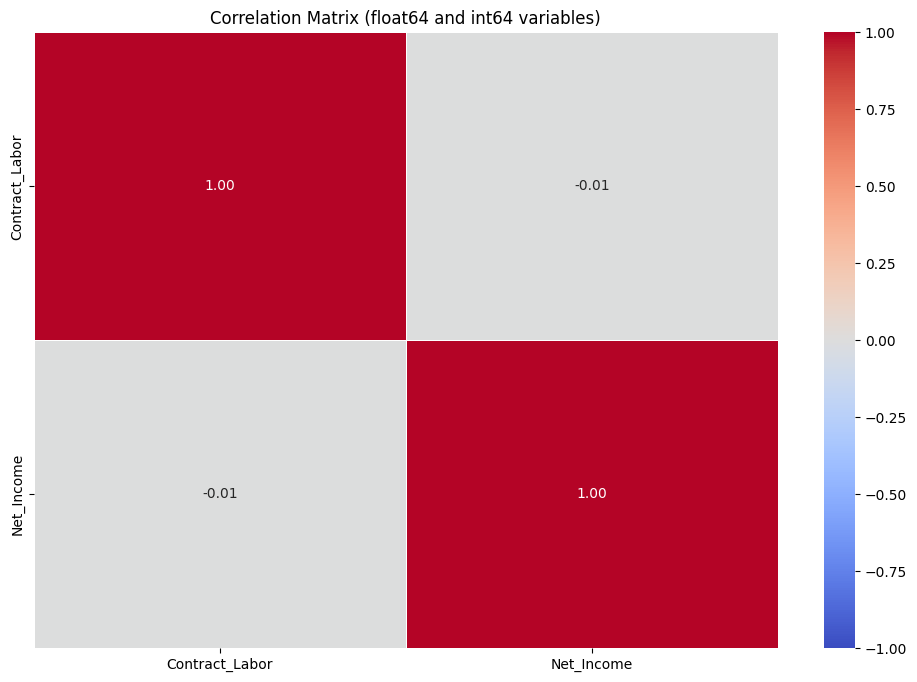

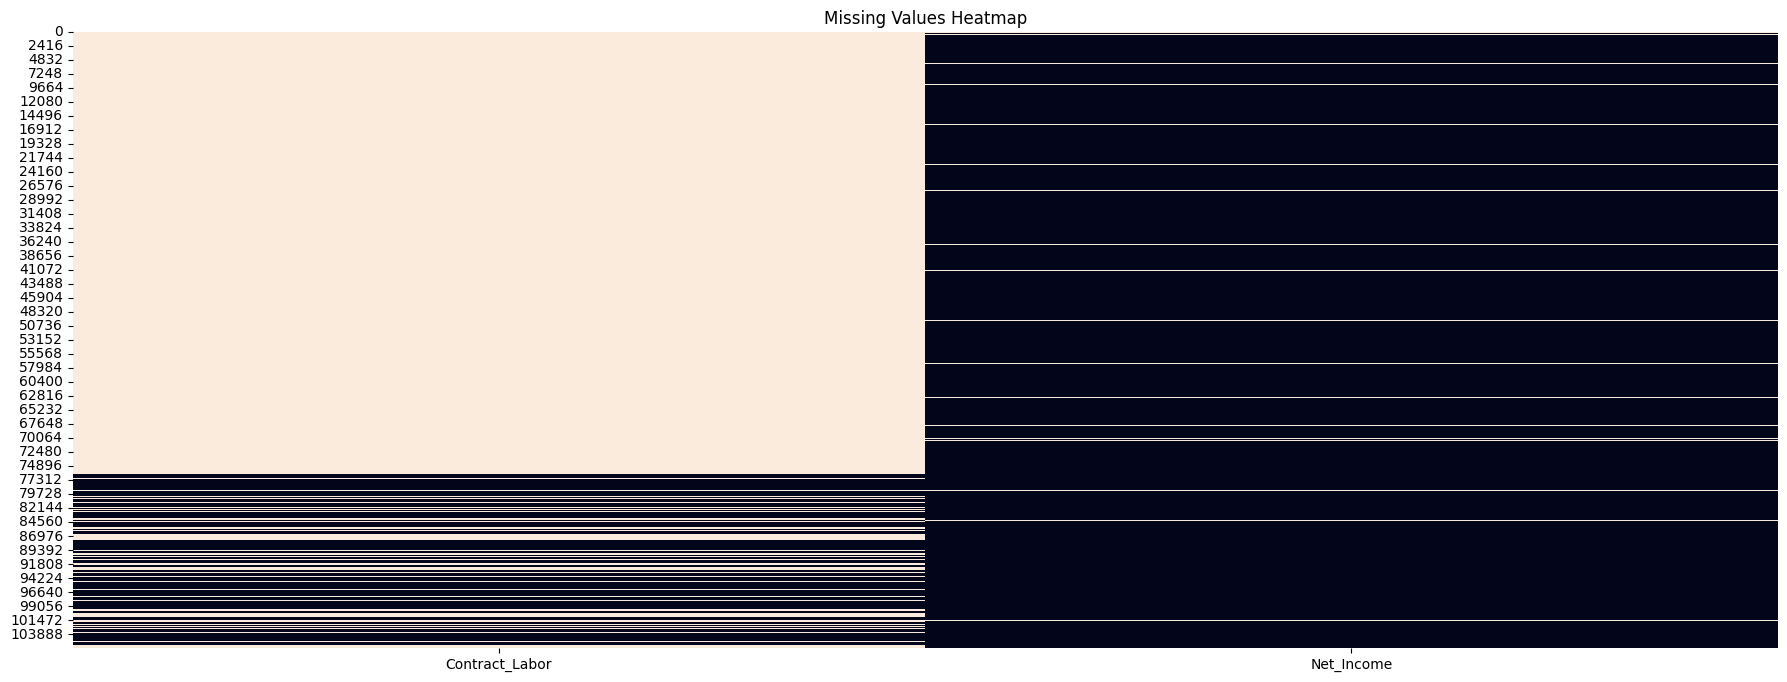

In [20]:
# Select numerical columns (float64 and int64)
num_cols = group.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix for the selected columns
corr_matrix = group[num_cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix (float64 and int64 variables)")
plt.show()

# Plot the missing values heatmap
plt.figure(figsize=(22, 8))
sns.heatmap(group.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [21]:
# Drop a specific column by name
df = df.drop(columns=['Contract_Labor'])


In [22]:
# Select columns that contain the word 'assets' and also include 'Net_Income'
assets_cols = [col for col in df.columns if 'notes' in col.lower()]
assets_cols.append('Net_Income')  # Add 'Net_Income' to the list

# Create a new DataFrame with only the selected columns
group = df[assets_cols]

# Display the selected columns

group.head()

,Less:_Allowances_for_uncollectible_notes_and_accounts_receivable,Notes_Payable,Net_Income
0,NaN,NaN,311430.0
1,NaN,NaN,-588469.0
2,NaN,NaN,-47859.0
3,NaN,NaN,-63638.0
4,NaN,NaN,-1613.0


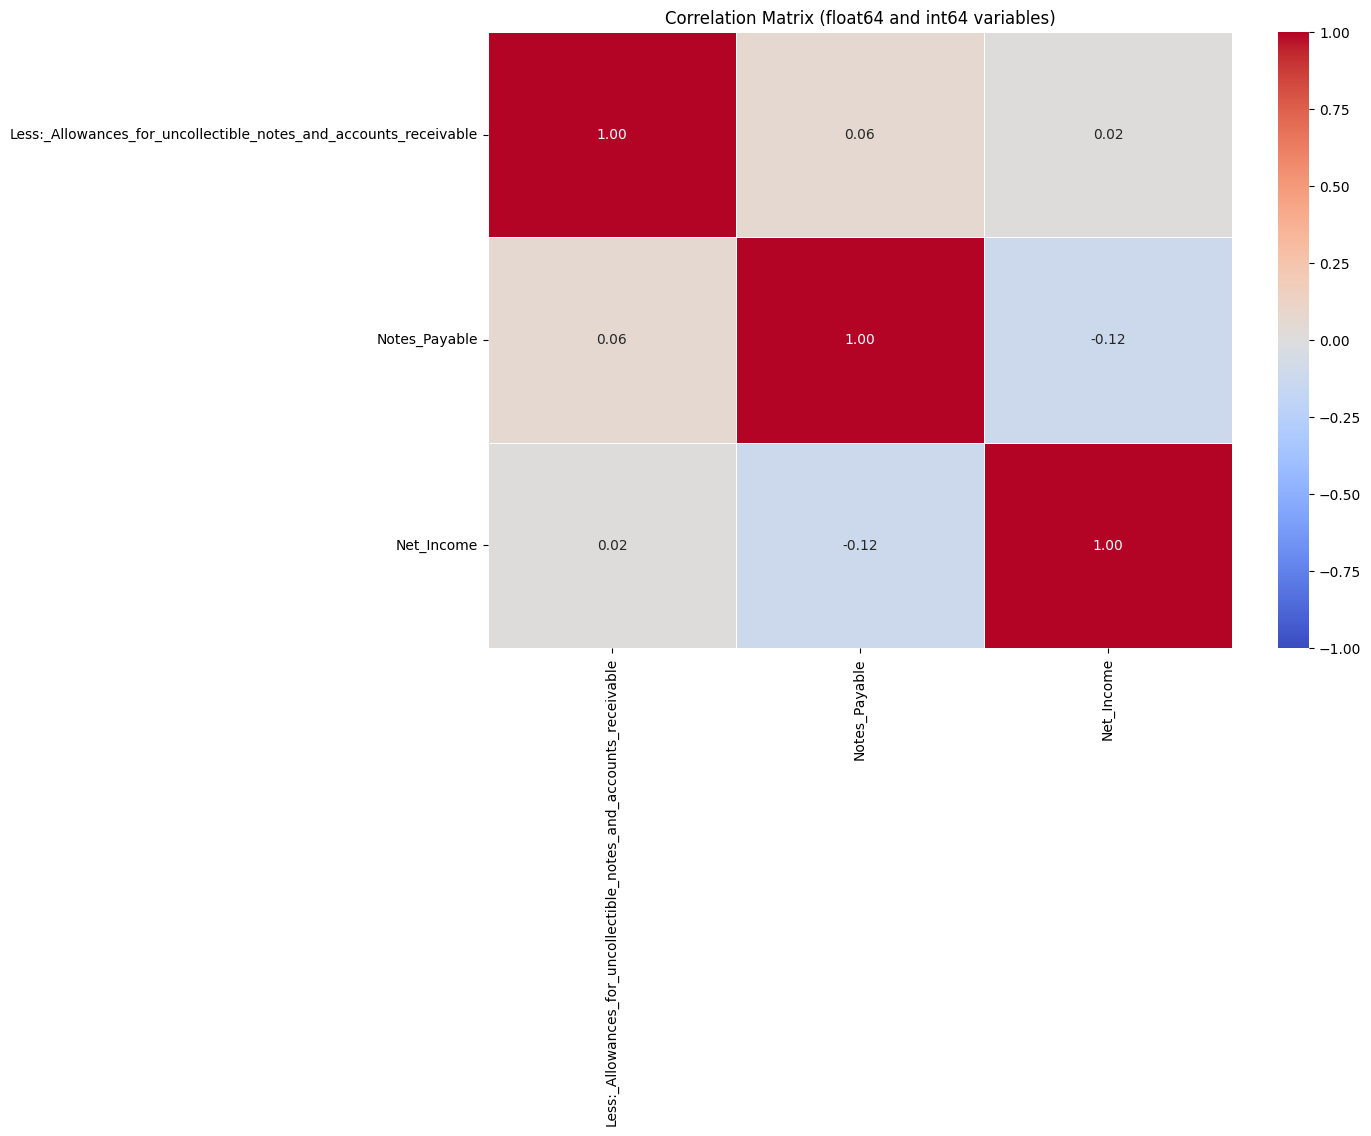

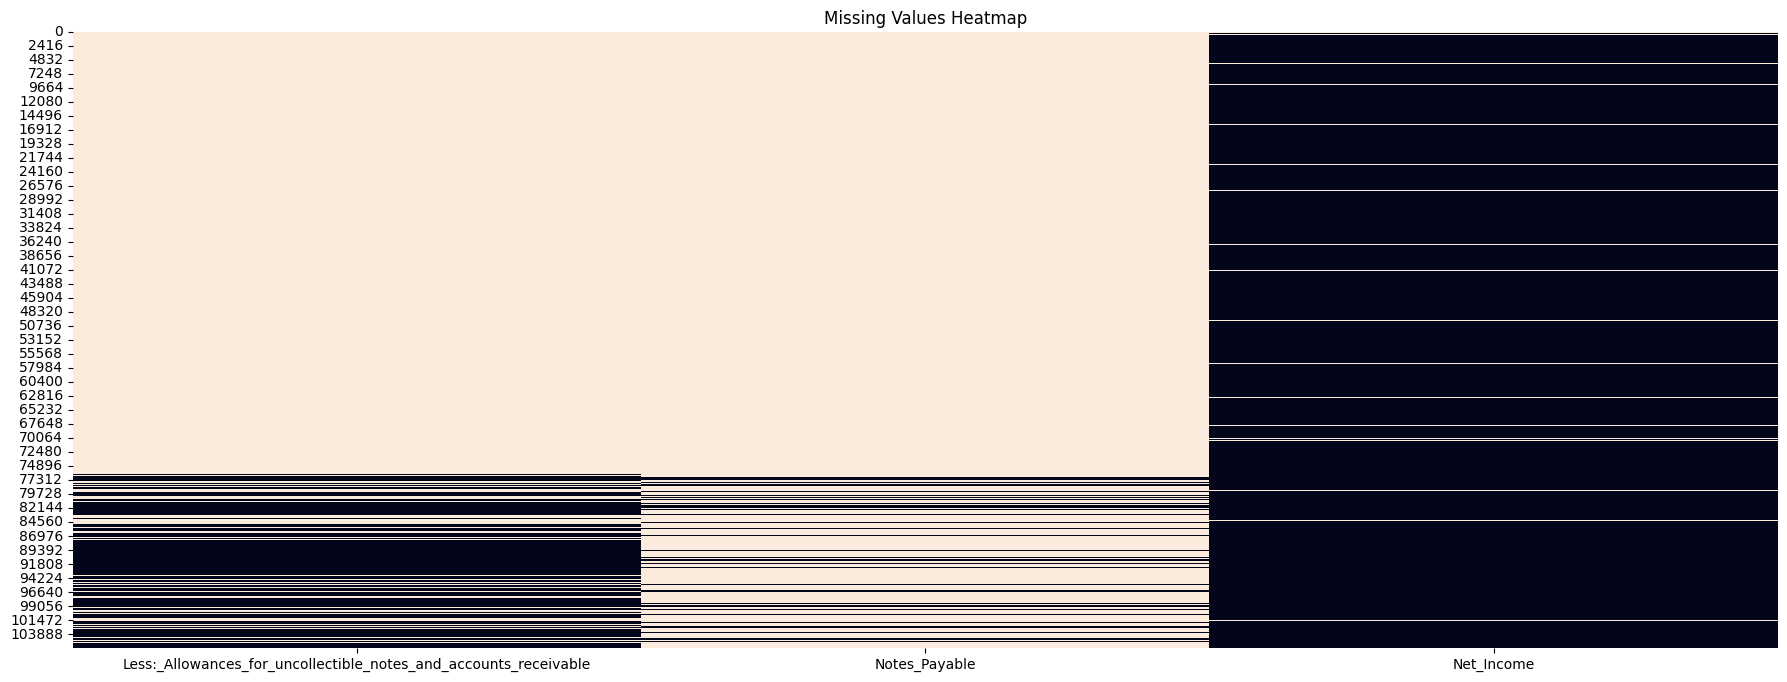

In [23]:
# Select numerical columns (float64 and int64)
num_cols = group.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix for the selected columns
corr_matrix = group[num_cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix (float64 and int64 variables)")
plt.show()

# Plot the missing values heatmap
plt.figure(figsize=(22, 8))
sns.heatmap(group.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [24]:
# Calculate percentage of missing values for each column
missing_percentage = group.isnull().mean() * 100

# Get the columns with more than 50% missing values
cols_to_check = missing_percentage[missing_percentage > 50].index

# Compute the correlation matrix for numerical columns
corr_matrix = group.select_dtypes(include=['float64', 'int64']).corr()

# Get the correlation of each column with 'Net_Income', excluding 'Net_Income' itself
correlation_with_net_income = corr_matrix['Net_Income'].drop('Net_Income').sort_values(ascending=False)

# Convert correlations to absolute values to ensure we are comparing magnitudes, not the direction
absolute_corr_with_net_income = correlation_with_net_income.abs()

# Identify the column with the highest absolute correlation
max_corr = absolute_corr_with_net_income.max()

# Identify columns to drop (those with less correlation than the maximum correlation)
columns_to_drop = []
for col in cols_to_check:
    # Ensure that the column exists in absolute correlation data before comparing
    if col in absolute_corr_with_net_income:
        if absolute_corr_with_net_income[col] < max_corr:  # Drop if its correlation is less than the max
            columns_to_drop.append(col)

# Drop the identified columns from the dataset
df = df.drop(columns=columns_to_drop)

# Print the columns that were dropped
print(f"Columns dropped due to >50% NA and lower absolute correlation with Net_Income: {columns_to_drop}")

# Optionally, display the cleaned dataset
# print(group_cleaned.head())

# Print correlation values for review
print("\nAbsolute Correlation with Net_Income:")
print(absolute_corr_with_net_income)


Columns dropped due to >50% NA and lower absolute correlation with Net_Income: ['Less:_Allowances_for_uncollectible_notes_and_accounts_receivable']

Absolute Correlation with Net_Income:
Less:_Allowances_for_uncollectible_notes_and_accounts_receivable    0.015206
Notes_Payable                                                       0.121031
Name: Net_Income, dtype: float64


In [25]:
# Select columns that contain the words 'land' or 'liabilities' and also include 'Net_Income'
selected_words = ['land', 'assets']
selected_cols = [col for col in df.columns if any(word in col.lower() for word in selected_words)]
selected_cols.append('Net_Income')  # Add 'Net_Income' to the list

# Create a new DataFrame with only the selected columns
group = df[selected_cols]

# Display the selected columns
group.head()


,Other_Assets,Total_Assets,Total_fixed_Assets,Total_other_Assets,Land_improvements,Other_current_assets,Total_Current_Assets,Land,Net_Income
0,NaN,765020.0,55061.0,-729268.0,NaN,NaN,1439227.0,NaN,311430.0
1,36000.0,1687456.0,671306.0,36000.0,NaN,NaN,980150.0,NaN,-588469.0
2,NaN,244239.0,NaN,NaN,NaN,NaN,244239.0,NaN,-47859.0
3,NaN,1830758.0,26949.0,74985.0,NaN,NaN,1728824.0,NaN,-63638.0
4,NaN,807209.0,NaN,NaN,NaN,NaN,807209.0,NaN,-1613.0


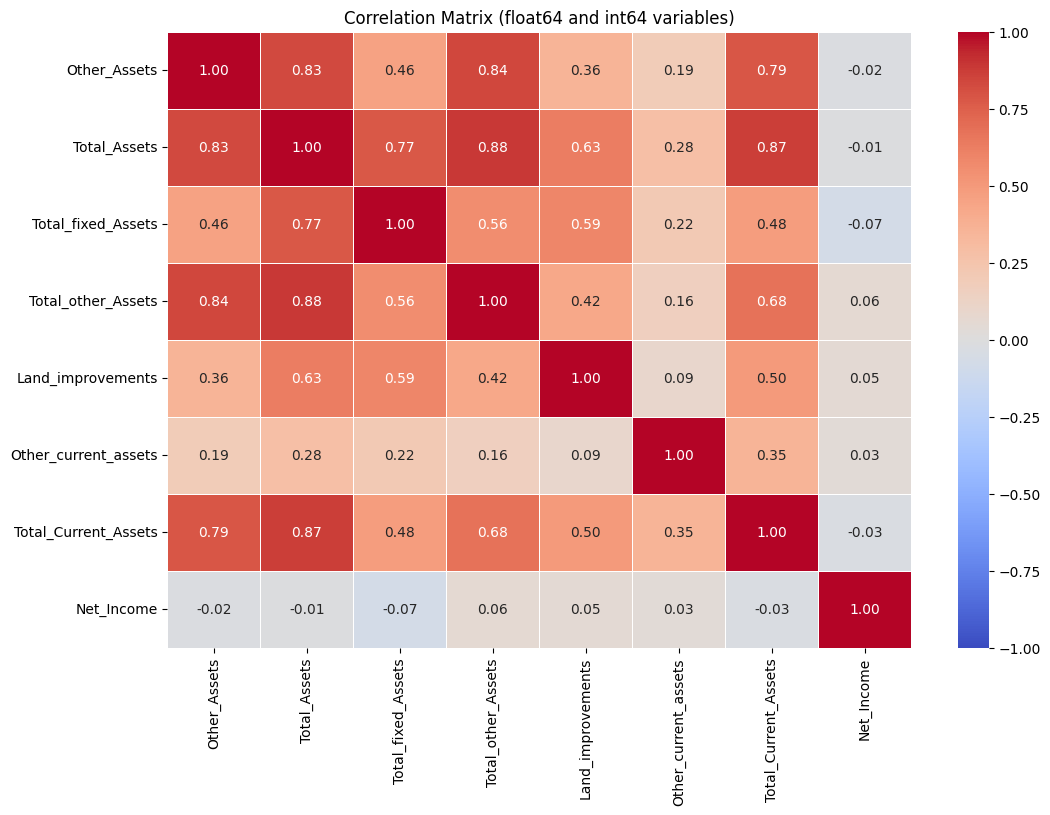

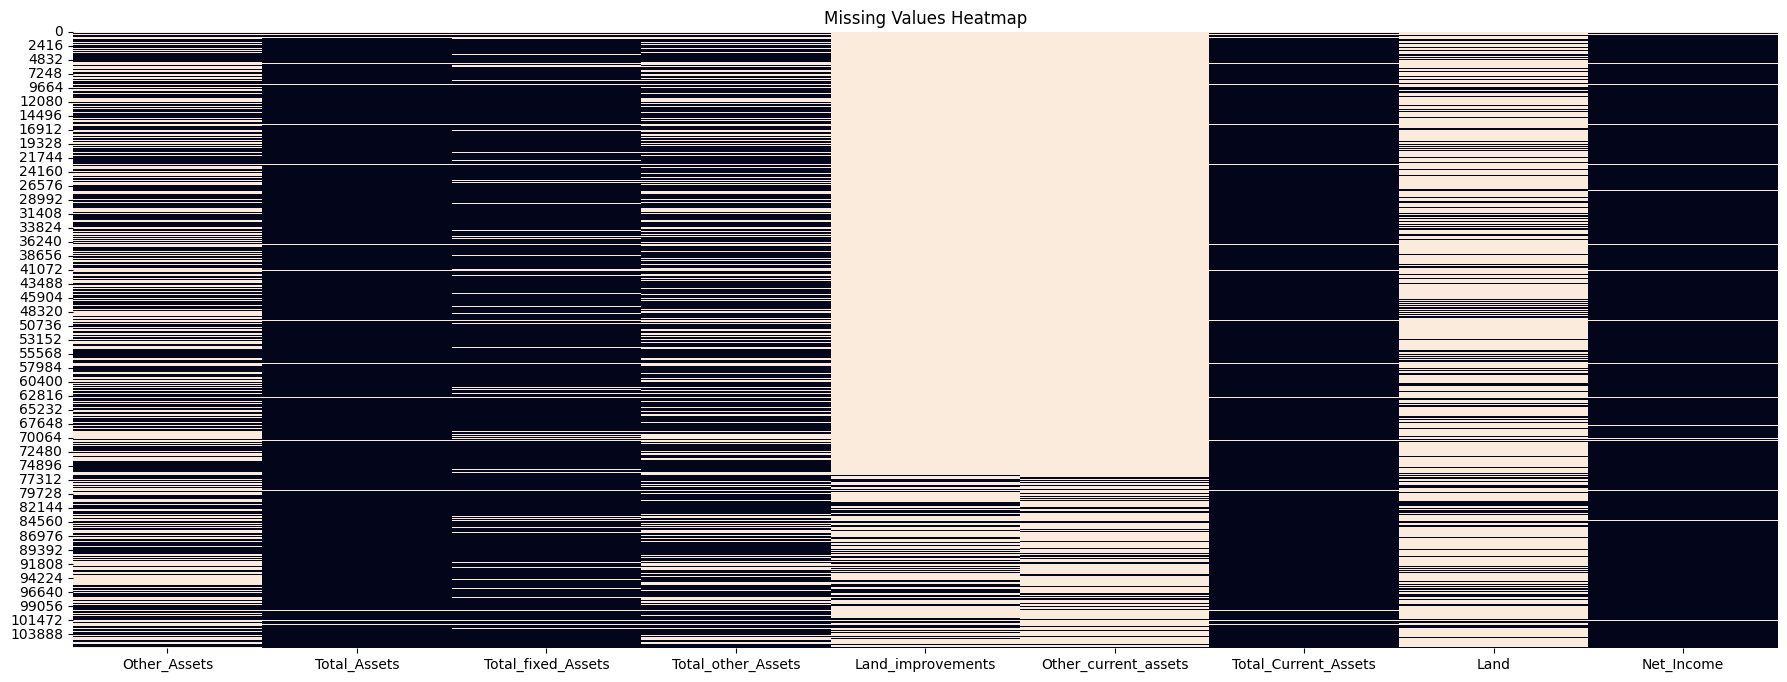

In [26]:
# Select numerical columns (float64 and int64)
num_cols = group.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix for the selected columns
corr_matrix = group[num_cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix (float64 and int64 variables)")
plt.show()

# Plot the missing values heatmap
plt.figure(figsize=(22, 8))
sns.heatmap(group.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [27]:
# Calculate percentage of missing values for each column
missing_percentage = group.isnull().mean() * 100

# Get the columns with more than 50% missing values
cols_to_check = missing_percentage[missing_percentage > 50].index

# Compute the correlation matrix for numerical columns
corr_matrix = group.select_dtypes(include=['float64', 'int64']).corr()

# Get the correlation of each column with 'Net_Income', excluding 'Net_Income' itself
correlation_with_net_income = corr_matrix['Net_Income'].drop('Net_Income').sort_values(ascending=False)

# Convert correlations to absolute values to ensure we are comparing magnitudes, not the direction
absolute_corr_with_net_income = correlation_with_net_income.abs()

# Identify the column with the highest absolute correlation
max_corr = absolute_corr_with_net_income.max()

# Identify columns to drop (those with less correlation than the maximum correlation)
columns_to_drop = []
for col in cols_to_check:
    # Ensure that the column exists in absolute correlation data before comparing
    if col in absolute_corr_with_net_income:
        if absolute_corr_with_net_income[col] < max_corr:  # Drop if its correlation is less than the max
            columns_to_drop.append(col)

# Drop the identified columns from the dataset
df = df.drop(columns=columns_to_drop)

# Print the columns that were dropped
print(f"Columns dropped due to >50% NA and lower absolute correlation with Net_Income: {columns_to_drop}")

# Optionally, display the cleaned dataset
# print(group_cleaned.head())

# Print correlation values for review
print("\nAbsolute Correlation with Net_Income:")
print(absolute_corr_with_net_income)

Columns dropped due to >50% NA and lower absolute correlation with Net_Income: ['Land_improvements', 'Other_current_assets']

Absolute Correlation with Net_Income:
Total_other_Assets      0.058940
Land_improvements       0.047184
Other_current_assets    0.032717
Total_Assets            0.013971
Other_Assets            0.022875
Total_Current_Assets    0.025012
Total_fixed_Assets      0.072134
Name: Net_Income, dtype: float64


In [28]:
# Select columns that contain the words 'land' or 'liabilities' and also include 'Net_Income'
selected_words = ['inventory', 'assets']
selected_cols = [col for col in df.columns if any(word in col.lower() for word in selected_words)]
selected_cols.append('Net_Income')  # Add 'Net_Income' to the list

# Create a new DataFrame with only the selected columns
group = df[selected_cols]

# Display the selected columns
group.head()


,Other_Assets,Total_Assets,Total_fixed_Assets,Total_other_Assets,Total_Current_Assets,Inventory,Net_Income
0,NaN,765020.0,55061.0,-729268.0,1439227.0,NaN,311430.0
1,36000.0,1687456.0,671306.0,36000.0,980150.0,NaN,-588469.0
2,NaN,244239.0,NaN,NaN,244239.0,NaN,-47859.0
3,NaN,1830758.0,26949.0,74985.0,1728824.0,NaN,-63638.0
4,NaN,807209.0,NaN,NaN,807209.0,NaN,-1613.0


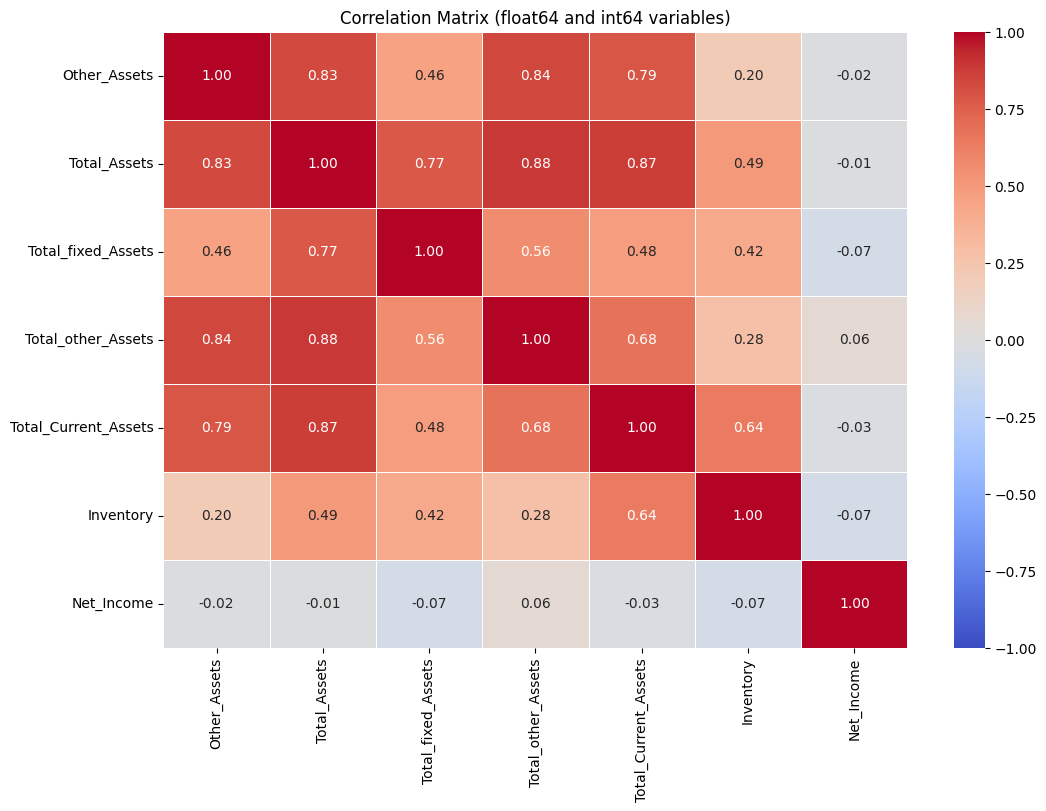

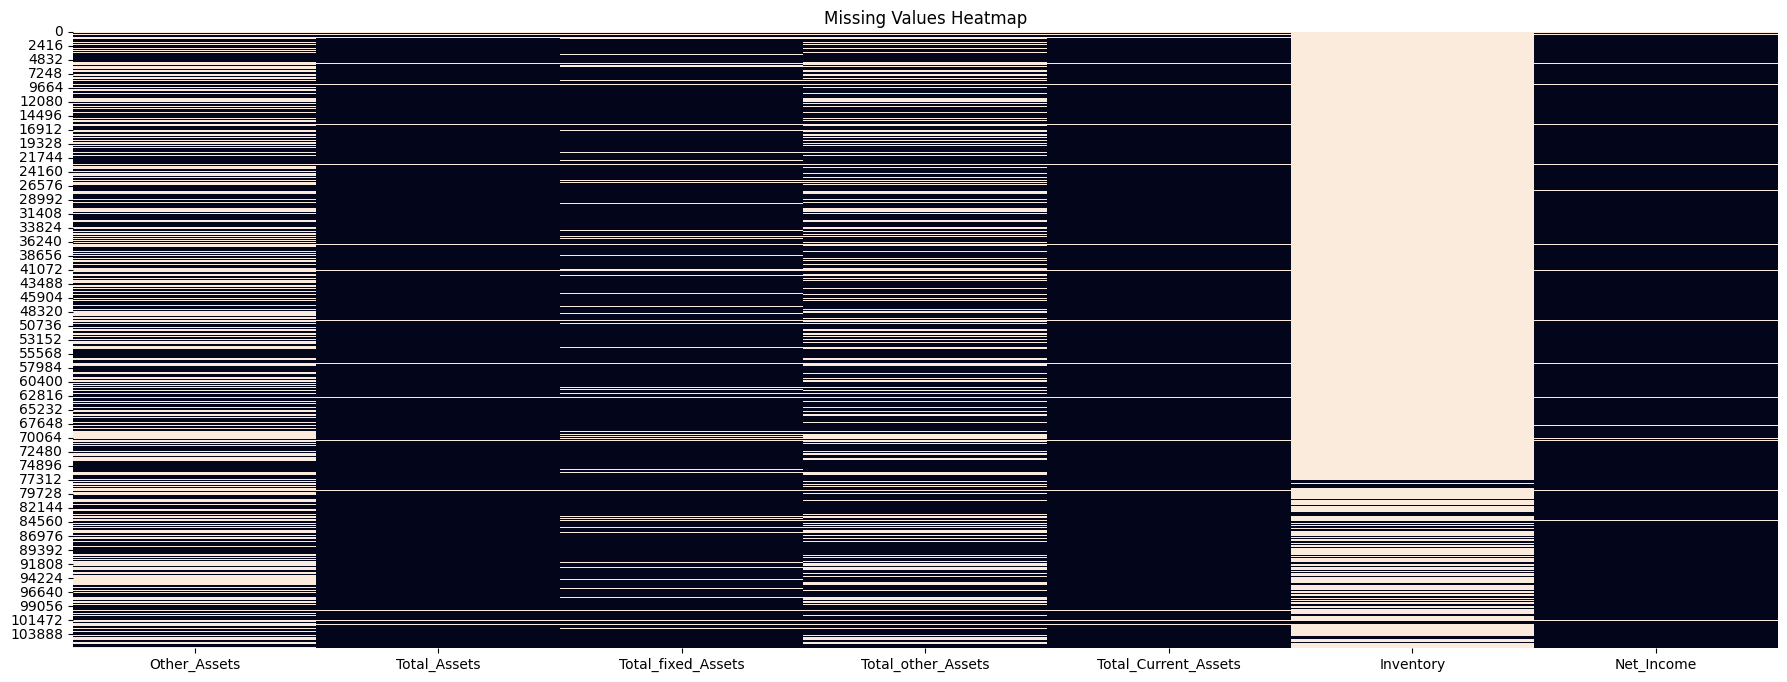

In [29]:
# Select numerical columns (float64 and int64)
num_cols = group.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix for the selected columns
corr_matrix = group[num_cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix (float64 and int64 variables)")
plt.show()

# Plot the missing values heatmap
plt.figure(figsize=(22, 8))
sns.heatmap(group.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [30]:
# Calculate percentage of missing values for each column
missing_percentage = group.isnull().mean() * 100

# Get the columns with more than 50% missing values
cols_to_check = missing_percentage[missing_percentage > 50].index

# Compute the correlation matrix for numerical columns
corr_matrix = group.select_dtypes(include=['float64', 'int64']).corr()

# Get the correlation of each column with 'Net_Income', excluding 'Net_Income' itself
correlation_with_net_income = corr_matrix['Net_Income'].drop('Net_Income').sort_values(ascending=False)

# Convert correlations to absolute values to ensure we are comparing magnitudes, not the direction
absolute_corr_with_net_income = correlation_with_net_income.abs()

# Identify the column with the highest absolute correlation
max_corr = absolute_corr_with_net_income.max()

# Identify columns to drop (those with less correlation than the maximum correlation)
columns_to_drop = []
for col in cols_to_check:
    # Ensure that the column exists in absolute correlation data before comparing
    if col in absolute_corr_with_net_income:
        if absolute_corr_with_net_income[col] < max_corr:  # Drop if its correlation is less than the max
            columns_to_drop.append(col)

# Drop the identified columns from the dataset
df = df.drop(columns=columns_to_drop)

# Print the columns that were dropped
print(f"Columns dropped due to >50% NA and lower absolute correlation with Net_Income: {columns_to_drop}")

# Optionally, display the cleaned dataset
# print(group_cleaned.head())

# Print correlation values for review
print("\nAbsolute Correlation with Net_Income:")
print(absolute_corr_with_net_income)

Columns dropped due to >50% NA and lower absolute correlation with Net_Income: ['Inventory']

Absolute Correlation with Net_Income:
Total_other_Assets      0.058940
Total_Assets            0.013971
Other_Assets            0.022875
Total_Current_Assets    0.025012
Inventory               0.070864
Total_fixed_Assets      0.072134
Name: Net_Income, dtype: float64


In [31]:
# Select columns that contain the words 'land' or 'liabilities' and also include 'Net_Income'
selected_words = ['investments', 'assets', 'lease']
selected_cols = [col for col in df.columns if any(word in col.lower() for word in selected_words)]
selected_cols.append('Net_Income')  # Add 'Net_Income' to the list

# Create a new DataFrame with only the selected columns
group = df[selected_cols]

# Display the selected columns
group.head()


,Other_Assets,Total_Assets,Total_fixed_Assets,Total_other_Assets,Investments,Total_Current_Assets,Leasehold_improvements,Net_Income
0,NaN,765020.0,55061.0,-729268.0,NaN,1439227.0,NaN,311430.0
1,36000.0,1687456.0,671306.0,36000.0,NaN,980150.0,NaN,-588469.0
2,NaN,244239.0,NaN,NaN,NaN,244239.0,NaN,-47859.0
3,NaN,1830758.0,26949.0,74985.0,NaN,1728824.0,NaN,-63638.0
4,NaN,807209.0,NaN,NaN,NaN,807209.0,NaN,-1613.0


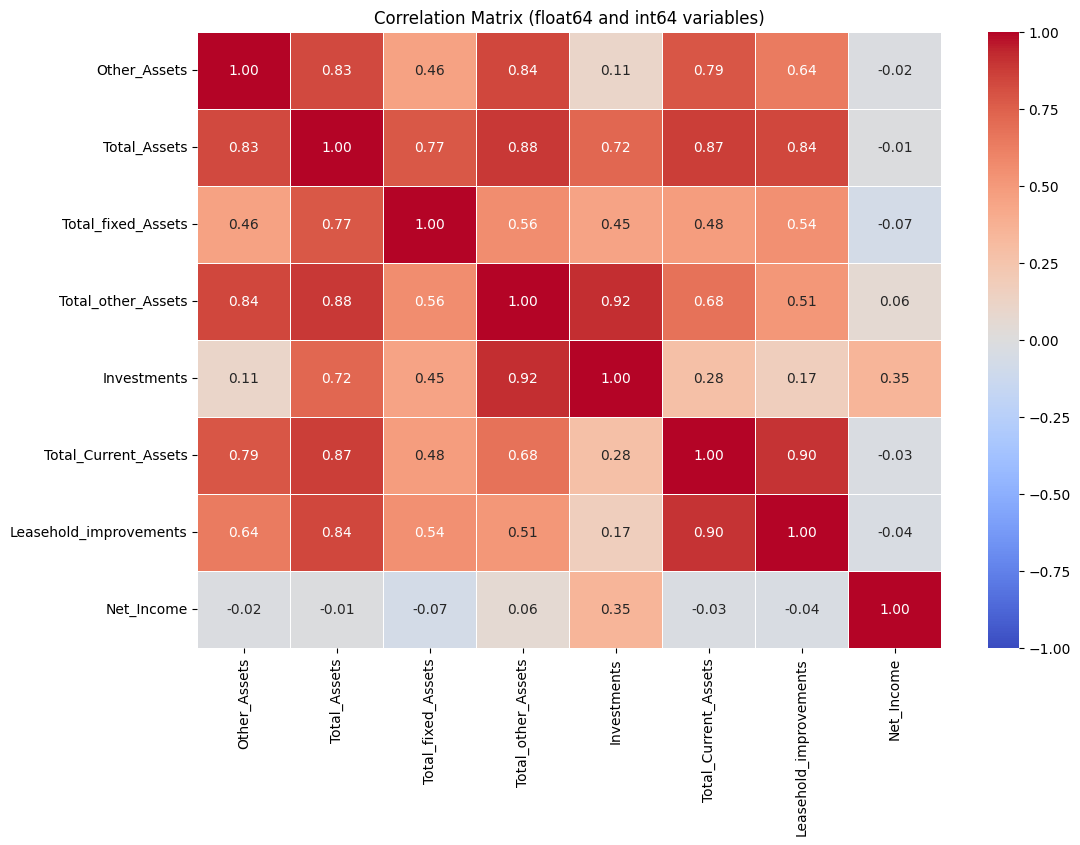

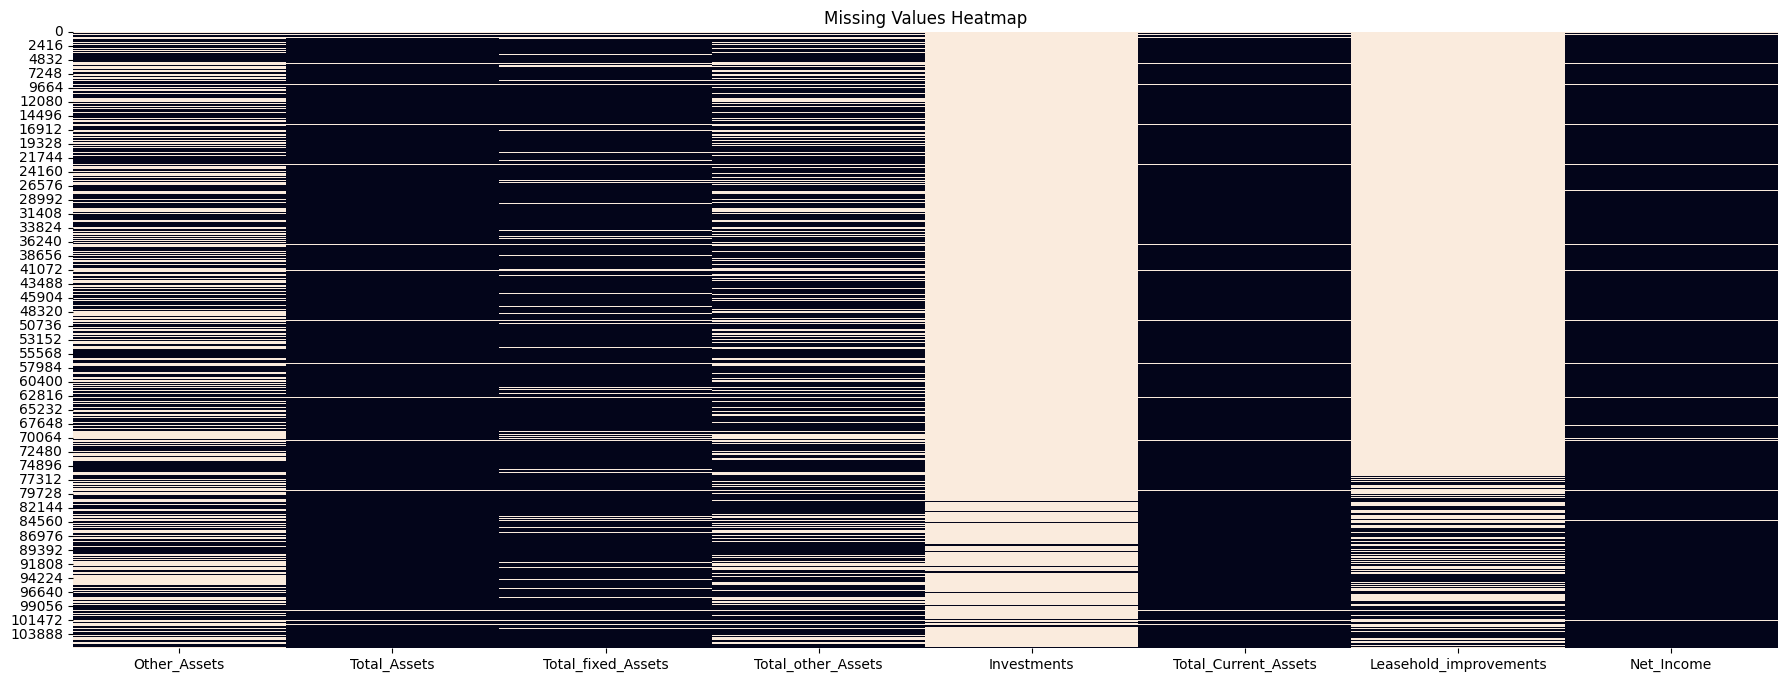

In [32]:
# Select numerical columns (float64 and int64)
num_cols = group.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix for the selected columns
corr_matrix = group[num_cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix (float64 and int64 variables)")
plt.show()

# Plot the missing values heatmap
plt.figure(figsize=(22, 8))
sns.heatmap(group.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [33]:
# Calculate percentage of missing values for each column
missing_percentage = group.isnull().mean() * 100

# Get the columns with more than 50% missing values
cols_to_check = missing_percentage[missing_percentage > 50].index

# Compute the correlation matrix for numerical columns
corr_matrix = group.select_dtypes(include=['float64', 'int64']).corr()

# Get the correlation of each column with 'Net_Income', excluding 'Net_Income' itself
correlation_with_net_income = corr_matrix['Net_Income'].drop('Net_Income').sort_values(ascending=False)

# Convert correlations to absolute values to ensure we are comparing magnitudes, not the direction
absolute_corr_with_net_income = correlation_with_net_income.abs()

# Identify the column with the highest absolute correlation
max_corr = absolute_corr_with_net_income.max()

# Identify columns to drop (those with less correlation than the maximum correlation)
columns_to_drop = []
for col in cols_to_check:
    # Ensure that the column exists in absolute correlation data before comparing
    if col in absolute_corr_with_net_income:
        if absolute_corr_with_net_income[col] < max_corr:  # Drop if its correlation is less than the max
            columns_to_drop.append(col)

# Drop the identified columns from the dataset
df = df.drop(columns=columns_to_drop)

# Print the columns that were dropped
print(f"Columns dropped due to >50% NA and lower absolute correlation with Net_Income: {columns_to_drop}")

# Optionally, display the cleaned dataset
# print(group_cleaned.head())

# Print correlation values for review
print("\nAbsolute Correlation with Net_Income:")
print(absolute_corr_with_net_income)

Columns dropped due to >50% NA and lower absolute correlation with Net_Income: ['Leasehold_improvements']

Absolute Correlation with Net_Income:
Investments               0.351033
Total_other_Assets        0.058940
Total_Assets              0.013971
Other_Assets              0.022875
Total_Current_Assets      0.025012
Leasehold_improvements    0.036853
Total_fixed_Assets        0.072134
Name: Net_Income, dtype: float64


In [34]:
# Select columns that contain the words 'land' or 'liabilities' and also include 'Net_Income'
selected_words = ['accounts', 'debts', 'assets']
selected_cols = [col for col in df.columns if any(word in col.lower() for word in selected_words)]
selected_cols.append('Net_Income')  # Add 'Net_Income' to the list

# Create a new DataFrame with only the selected columns
group = df[selected_cols]

# Display the selected columns
group.head()


,Accounts_Receivable,Accounts_payable,Other_Assets,Total_Assets,Total_fixed_Assets,Total_other_Assets,Allowable_Bad_Debts,Total_Current_Assets,Net_Income
0,1366877.0,292277.0,NaN,765020.0,55061.0,-729268.0,NaN,1439227.0,311430.0
1,1326379.0,NaN,36000.0,1687456.0,671306.0,36000.0,NaN,980150.0,-588469.0
2,135859.0,79894.0,NaN,244239.0,NaN,NaN,NaN,244239.0,-47859.0
3,1222903.0,537451.0,NaN,1830758.0,26949.0,74985.0,NaN,1728824.0,-63638.0
4,634347.0,253637.0,NaN,807209.0,NaN,NaN,NaN,807209.0,-1613.0


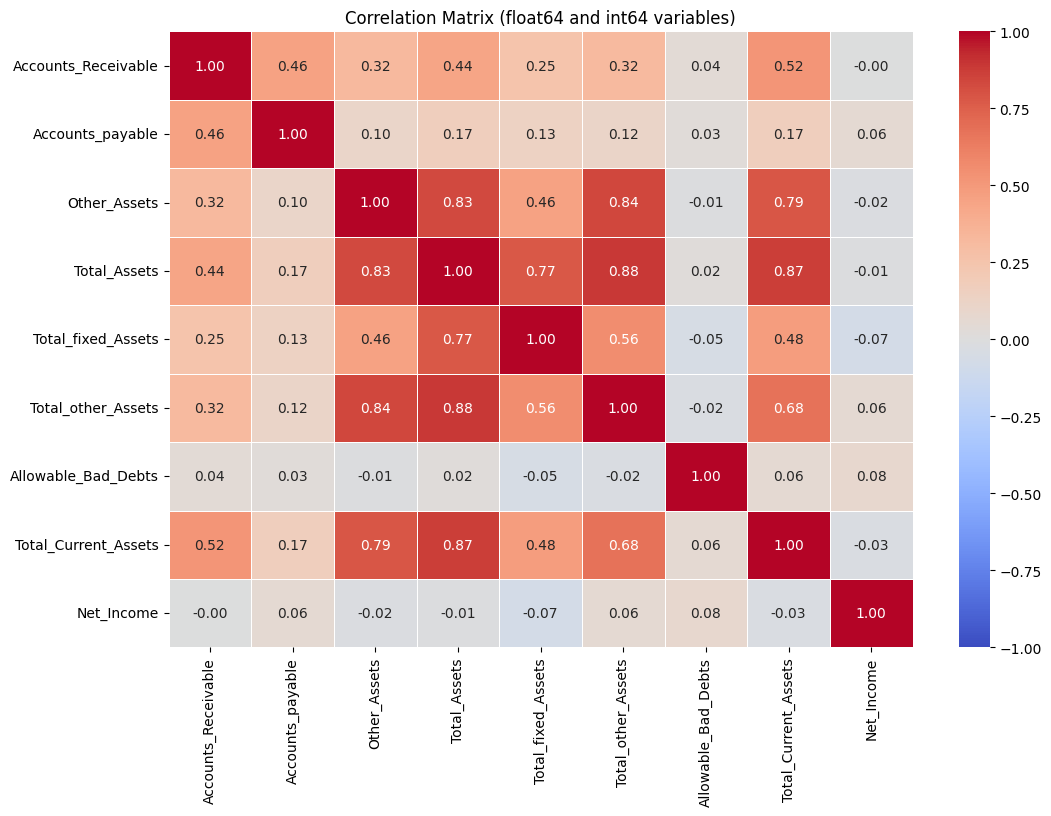

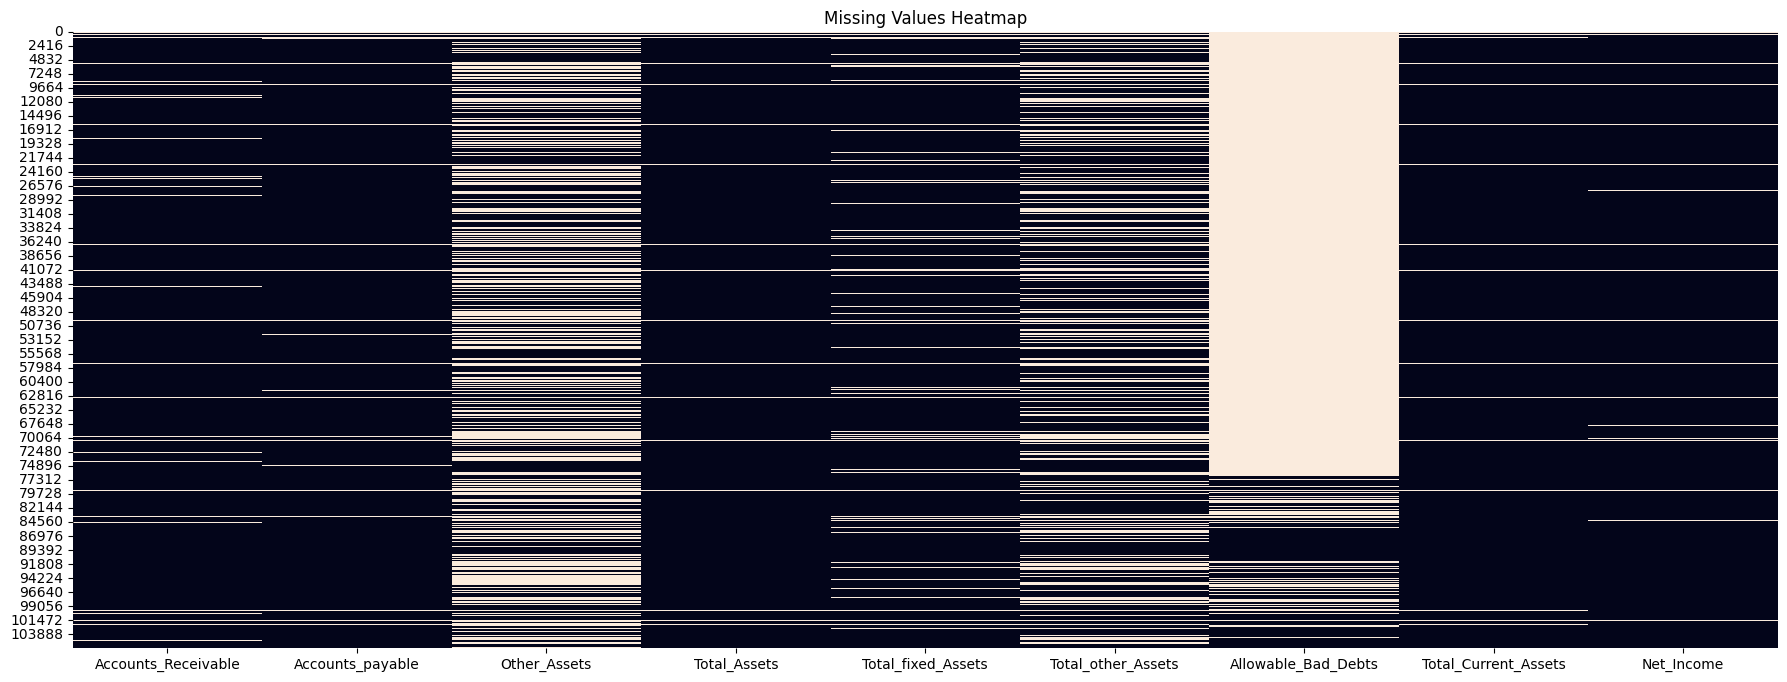

In [35]:
# Select numerical columns (float64 and int64)
num_cols = group.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix for the selected columns
corr_matrix = group[num_cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix (float64 and int64 variables)")
plt.show()

# Plot the missing values heatmap
plt.figure(figsize=(22, 8))
sns.heatmap(group.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [36]:
# Calculate percentage of missing values for each column
missing_percentage = group.isnull().mean() * 100

# Get the columns with more than 50% missing values
cols_to_check = missing_percentage[missing_percentage > 50].index

# Compute the correlation matrix for numerical columns
corr_matrix = group.select_dtypes(include=['float64', 'int64']).corr()

# Get the correlation of each column with 'Net_Income', excluding 'Net_Income' itself
correlation_with_net_income = corr_matrix['Net_Income'].drop('Net_Income').sort_values(ascending=False)

# Convert correlations to absolute values to ensure we are comparing magnitudes, not the direction
absolute_corr_with_net_income = correlation_with_net_income.abs()

# Identify the column with the highest absolute correlation
max_corr = absolute_corr_with_net_income.max()

# Identify columns to drop (those with less correlation than the maximum correlation)
columns_to_drop = []
for col in cols_to_check:
    # Ensure that the column exists in absolute correlation data before comparing
    if col in absolute_corr_with_net_income:
        if absolute_corr_with_net_income[col] < max_corr:  # Drop if its correlation is less than the max
            columns_to_drop.append(col)

# Drop the identified columns from the dataset
df = df.drop(columns=columns_to_drop)

# Print the columns that were dropped
print(f"Columns dropped due to >50% NA and lower absolute correlation with Net_Income: {columns_to_drop}")

# Optionally, display the cleaned dataset
# print(group_cleaned.head())

# Print correlation values for review
print("\nAbsolute Correlation with Net_Income:")
print(absolute_corr_with_net_income)

Columns dropped due to >50% NA and lower absolute correlation with Net_Income: []

Absolute Correlation with Net_Income:
Allowable_Bad_Debts     0.084392
Total_other_Assets      0.058940
Accounts_payable        0.058095
Accounts_Receivable     0.001690
Total_Assets            0.013971
Other_Assets            0.022875
Total_Current_Assets    0.025012
Total_fixed_Assets      0.072134
Name: Net_Income, dtype: float64


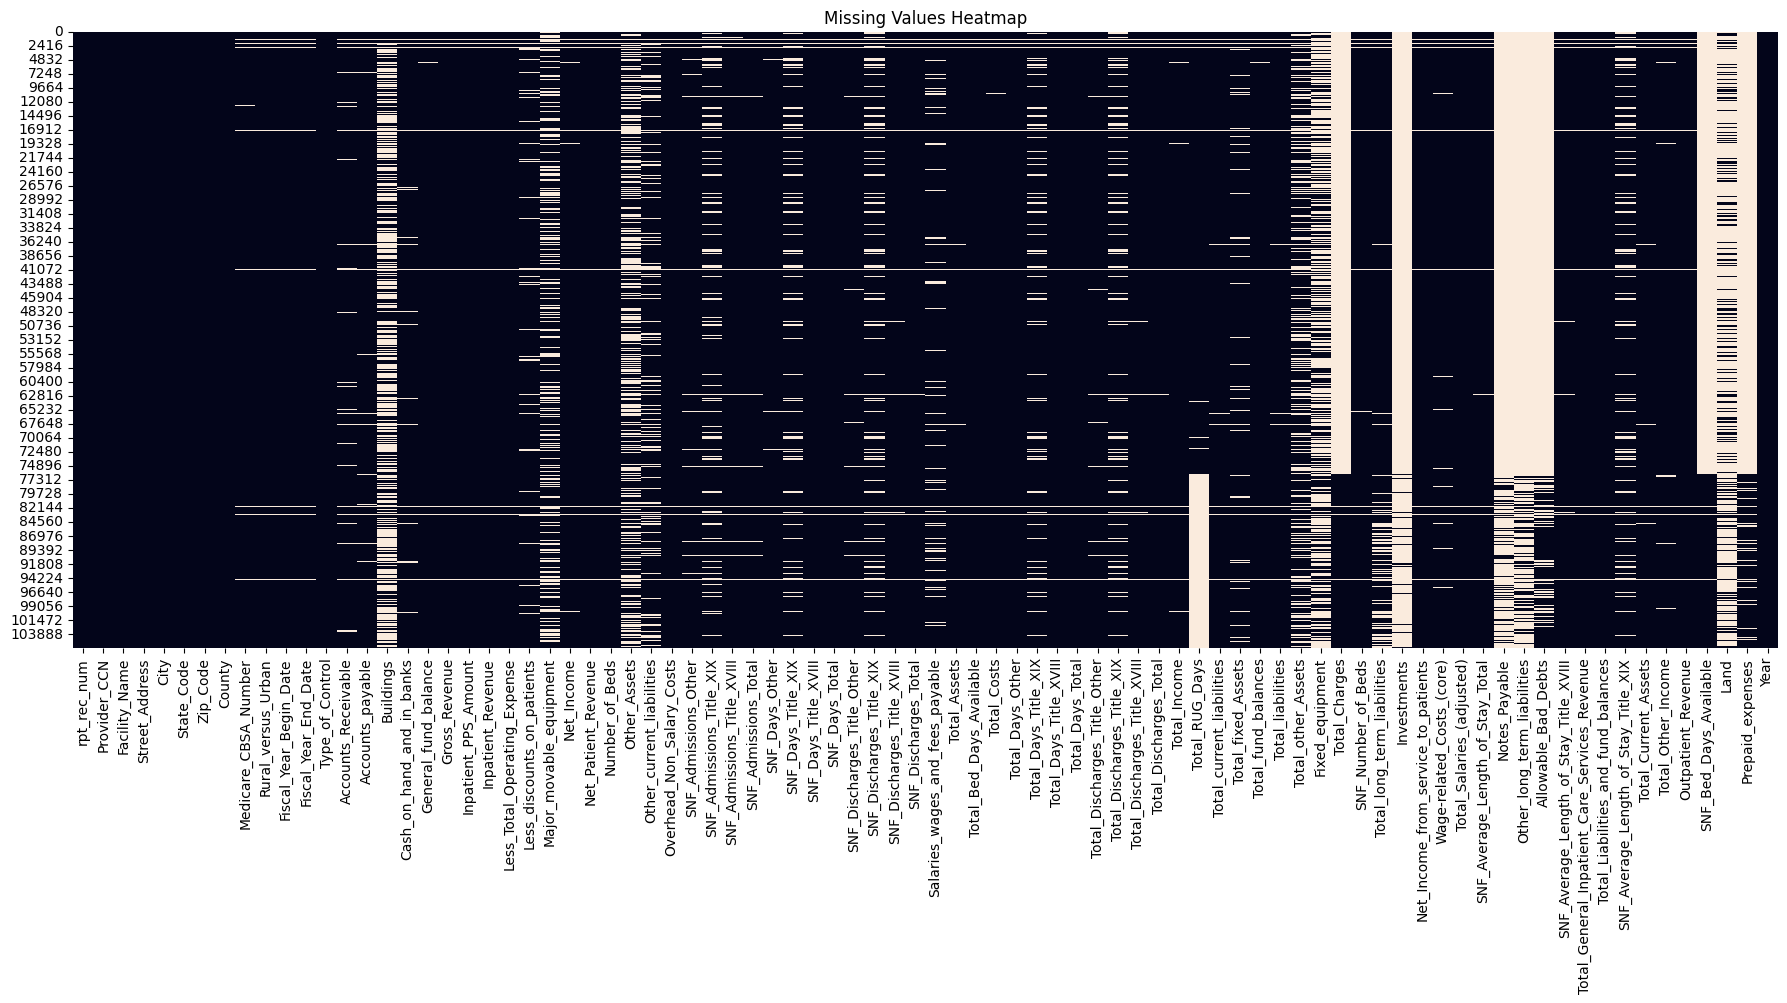

In [37]:
# Plot the missing values heatmap
plt.figure(figsize=(22, 8))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


### I have this dataset that are mostly filled variables and important, highly correlated NA variables. I will save this dataset as an option to use in my analysis. But I will further narrow this dataset down to more important variables based on correlation and the groups I initially made. 

In [38]:
# Count the total number of columns in df
num_columns = df.shape[1]

# Display the count
print(f"Total number of variables in df: {num_columns}")

Total number of variables in df: 84


# Limitations 
1. I dropped the columns that were 50% or more NA based on correlation but in groups. The groups were based on related words in the variable. I could've seperated it a different way statistically. 
2. I still have 13 columns with more than 50% missing data. I keep these because they are statistically important to Net_Income compared to other similarly grouped columns. 
3. I went from 90+ columns to 83.

In [39]:
# Export df_Cost to a CSV file
df.to_csv('df_filled_important.csv', index=False)
# then move it to the dataset folder

ASk Ai to seperate the varaibles in groups by relevant 

In [40]:
df# Define the groups
groups = {
    "financial_performance": [
        "Net_Income",
        "Gross_Revenue",
        "Net_Patient_Revenue",
        "Less_Total_Operating_Expense",
        "Less_discounts_on_patients",
        "Total_Income",
        "Total_Charges",
        "Total_Other_Income",
        "Net_Income_from_service_to_patients",
        "Allowable_Bad_Debts",
        "Wage-related_Costs_(core)",
        "Total_Salaries_(adjusted)"
    ],
    "assets_liabilities": [
        "Net_Income",
        "Accounts_Receivable",
        "Accounts_payable",
        "Cash_on_hand_and_in_banks",
        "Total_Assets",
        "Other_Assets",
        "Other_long_term_liabilities",
        "Other_current_liabilities",
        "Total_current_liabilities",
        "Total_long_term_liabilities",
        "Total_liabilities",
        "Total_Liabilities_and_fund_balances",
        "Total_fixed_Assets",
        "Total_fund_balances",
        "Total_other_Assets",
        "Total_Current_Assets",
        "Investments",
        "Buildings",
        "Major_movable_equipment",
        "Fixed_equipment",
        "Land",
        "Prepaid_expenses",
        "Notes_Payable"
    ],
    "patient_care": [
        "Net_Income",
        "Inpatient_PPS_Amount",
        "Inpatient_Revenue",
        "SNF_Admissions_Other",
        "SNF_Admissions_Title_XIX",
        "SNF_Admissions_Title_XVIII",
        "SNF_Admissions_Total",
        "SNF_Days_Other",
        "SNF_Days_Title_XIX",
        "SNF_Days_Title_XVIII",
        "SNF_Days_Total",
        "SNF_Discharges_Title_Other",
        "SNF_Discharges_Title_XIX",
        "SNF_Discharges_Title_XVIII",
        "SNF_Discharges_Total",
        "Total_General_Inpatient_Care_Services_Revenue"
    ],
    "facility_operations": [
        "Net_Income",
        "rpt_rec_num",
        "Provider_CCN",
        "Facility_Name",
        "Street_Address",
        "City",
        "State_Code",
        "Zip_Code",
        "County",
        "Medicare_CBSA_Number",
        "Rural_versus_Urban",
        "Fiscal_Year_Begin_Date",
        "Fiscal_Year_End_Date",
        "Type_of_Control",
        "Total_Bed_Days_Available",
        "Total_Days_Other",
        "Total_Days_Title_XIX",
        "Total_Days_Title_XVIII",
        "Total_Days_Total",
        "Total_Discharges_Title_Other",
        "Total_Discharges_Title_XIX",
        "Total_Discharges_Title_XVIII",
        "Total_Discharges_Total",
        "Total_RUG_Days",
        "Total_Costs",
        "SNF_Number_of_Beds",
        "SNF_Average_Length_of_Stay_Total",
        "SNF_Average_Length_of_Stay_Title_XVIII",
        "SNF_Average_Length_of_Stay_Title_XIX",
        "SNF_Bed_Days_Available",
        "Year"
    ]
}

# Select a specific group
selected_group = "financial_performance"  # Change this to switch groups
group_df = df[groups[selected_group]]

# Display the first few rows
group_df.head()


,Net_Income,Gross_Revenue,Net_Patient_Revenue,Less_Total_Operating_Expense,Less_discounts_on_patients,Total_Income,Total_Charges,Total_Other_Income,Net_Income_from_service_to_patients,Allowable_Bad_Debts,Wage-related_Costs_(core),Total_Salaries_(adjusted)
0,311430.0,1800296.0,1520630.0,1209322.0,279666.0,311431.0,NaN,1.0,311308.0,NaN,80664.0,660232.0
1,-588469.0,2843541.0,2416825.0,3005301.0,426716.0,-588469.0,NaN,0.0,-588476.0,NaN,559430.0,1118860.0
2,-47859.0,613243.0,600033.0,639168.0,13210.0,-30743.0,NaN,17116.0,-39135.0,NaN,42209.0,348614.0
3,-63638.0,1935277.0,1378163.0,1444469.0,557114.0,-63638.0,NaN,0.0,-66306.0,NaN,113676.0,601118.0
4,-1613.0,818175.0,769155.0,775242.0,49020.0,-1613.0,NaN,0.0,-6087.0,NaN,99778.0,363088.0


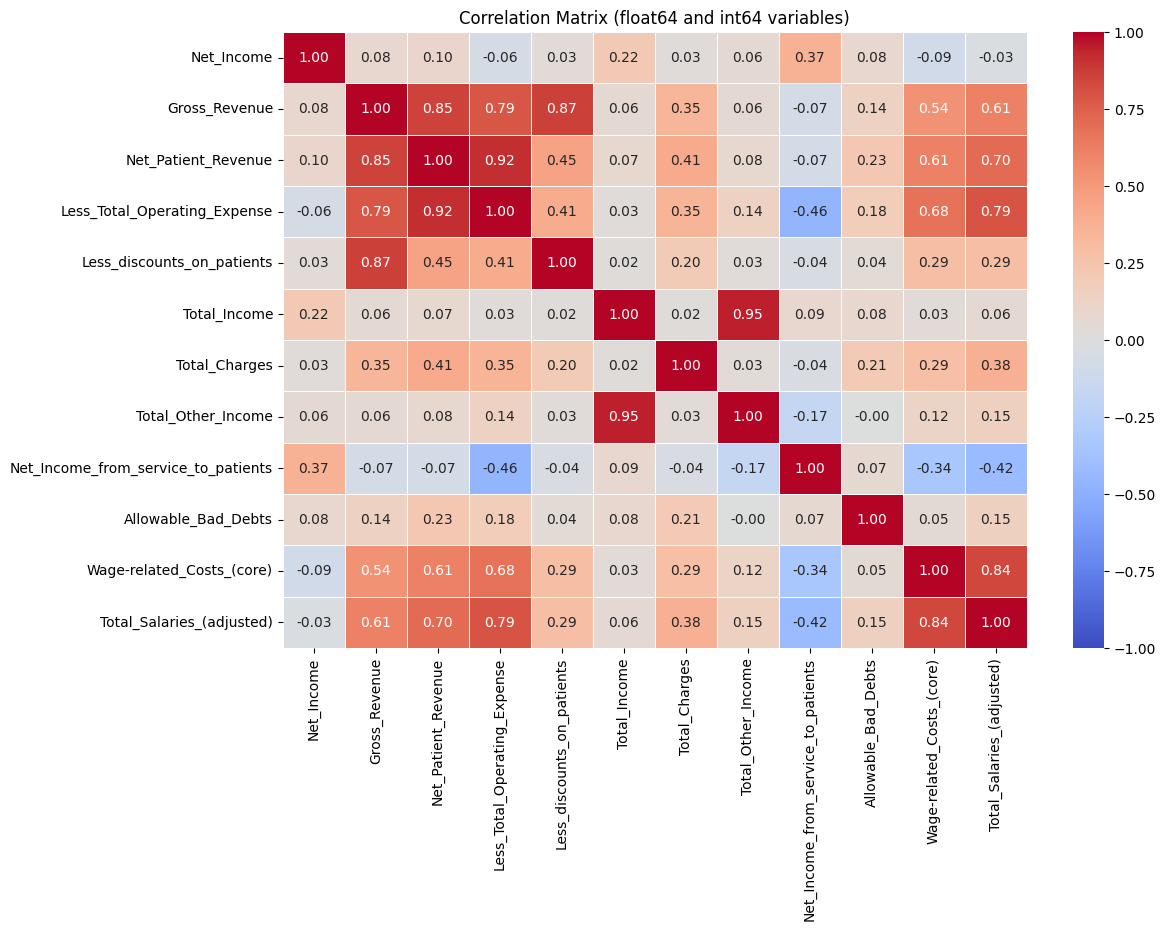

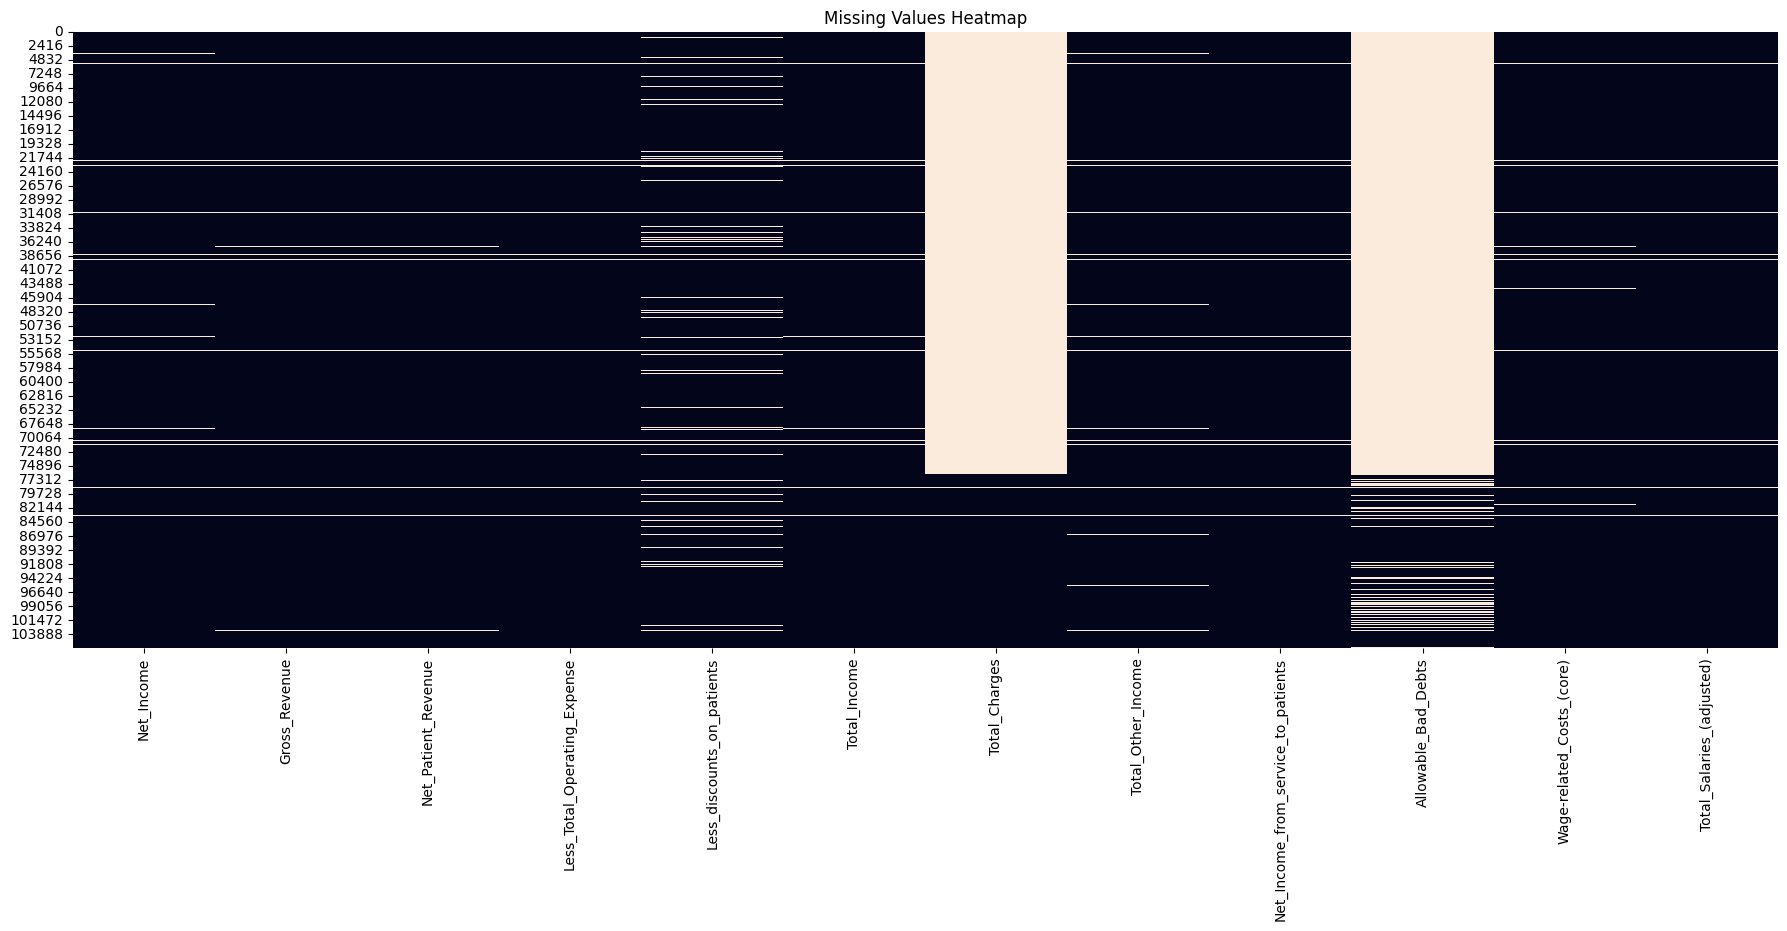

In [41]:
# Select numerical columns (float64 and int64)
num_cols = group_df.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix for the selected columns
corr_matrix = group_df[num_cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix (float64 and int64 variables)")
plt.show()

# Plot the missing values heatmap
plt.figure(figsize=(22, 8))
sns.heatmap(group_df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [42]:
import numpy as np

# Compute correlation matrix for numerical columns
corr_matrix = group_df.select_dtypes(include=['float64', 'int64']).corr().abs()

# Identify pairs with high correlation (>= 0.7)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):  # Avoid duplicates
        if corr_matrix.iloc[i, j] >= 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

# Convert list to DataFrame for better visualization
import pandas as pd
high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Variable_1', 'Variable_2', 'Correlation'])

# Display highly correlated variable pairs
print("Highly Correlated Pairs (|r| ≥ 0.7):")
print(high_corr_df)


Highly Correlated Pairs (|r| ≥ 0.7):
                     Variable_1                    Variable_2  Correlation
0                 Gross_Revenue           Net_Patient_Revenue     0.853230
1                 Gross_Revenue  Less_Total_Operating_Expense     0.785612
2                 Gross_Revenue    Less_discounts_on_patients     0.865487
3           Net_Patient_Revenue  Less_Total_Operating_Expense     0.916996
4           Net_Patient_Revenue     Total_Salaries_(adjusted)     0.704430
5  Less_Total_Operating_Expense     Total_Salaries_(adjusted)     0.794406
6                  Total_Income            Total_Other_Income     0.948232
7     Wage-related_Costs_(core)     Total_Salaries_(adjusted)     0.841402


In [43]:
# Compute correlation of each variable with Net_Income
correlation_with_net_income = corr_matrix["Net_Income"]

# List of variables to drop (the ones with lower correlation with Net_Income)
vars_to_drop = []
net_income_correlations = []  # Store correlations of both variables for reference

for var1, var2, _ in high_corr_pairs:
    cor_var1 = correlation_with_net_income[var1]
    cor_var2 = correlation_with_net_income[var2]

    # Store correlations for reference
    net_income_correlations.append((var1, cor_var1))
    net_income_correlations.append((var2, cor_var2))

    # Drop the variable with the lower absolute correlation with Net_Income
    if abs(cor_var1) < abs(cor_var2):
        vars_to_drop.append(var1)
    else:
        vars_to_drop.append(var2)

# Remove duplicates (in case the same variable appeared multiple times)
vars_to_drop = list(set(vars_to_drop))

# Convert to DataFrame for better visualization
net_income_cor_df = pd.DataFrame(net_income_correlations, columns=["Variable", "Correlation_with_Net_Income"]).drop_duplicates()

# Display variables to be dropped and their correlations
print("Variables to drop due to multicollinearity:")
print(vars_to_drop)

# Display the correlation of all variables involved in multicollinearity with Net_Income
print("\nCorrelation of Multicollinear Variables with Net_Income:")
print(net_income_cor_df)


Variables to drop due to multicollinearity:
['Total_Salaries_(adjusted)', 'Gross_Revenue', 'Less_discounts_on_patients', 'Total_Other_Income', 'Less_Total_Operating_Expense']

Correlation of Multicollinear Variables with Net_Income:
                        Variable  Correlation_with_Net_Income
0                  Gross_Revenue                     0.081916
1            Net_Patient_Revenue                     0.098571
3   Less_Total_Operating_Expense                     0.059590
5     Less_discounts_on_patients                     0.031532
9      Total_Salaries_(adjusted)                     0.026775
12                  Total_Income                     0.216579
13            Total_Other_Income                     0.057727
14     Wage-related_Costs_(core)                     0.088911


In [44]:
# Drop the lesser correlated variables
df = df.drop(columns=vars_to_drop)

# Display the cleaned DataFrame
print("Dataset after dropping multicollinear variables:")
df.head()


Dataset after dropping multicollinear variables:


,rpt_rec_num,Provider_CCN,Facility_Name,Street_Address,City,State_Code,Zip_Code,County,Medicare_CBSA_Number,Rural_versus_Urban,Fiscal_Year_Begin_Date,Fiscal_Year_End_Date,Type_of_Control,Accounts_Receivable,Accounts_payable,Buildings,Cash_on_hand_and_in_banks,General_fund_balance,Inpatient_PPS_Amount,Inpatient_Revenue,Major_movable_equipment,Net_Income,Net_Patient_Revenue,Number_of_Beds,Other_Assets,Other_current_liabilities,Overhead_Non_Salary_Costs,SNF_Admissions_Other,SNF_Admissions_Title_XIX,SNF_Admissions_Title_XVIII,SNF_Admissions_Total,SNF_Days_Other,SNF_Days_Title_XIX,SNF_Days_Title_XVIII,SNF_Days_Total,SNF_Discharges_Title_Other,SNF_Discharges_Title_XIX,SNF_Discharges_Title_XVIII,SNF_Discharges_Total,Salaries_wages_and_fees_payable,Total_Assets,Total_Bed_Days_Available,Total_Costs,Total_Days_Other,Total_Days_Title_XIX,Total_Days_Title_XVIII,Total_Days_Total,Total_Discharges_Title_Other,Total_Discharges_Title_XIX,Total_Discharges_Title_XVIII,Total_Discharges_Total,Total_Income,Total_RUG_Days,Total_current_liabilities,Total_fixed_Assets,Total_fund_balances,Total_liabilities,Total_other_Assets,Fixed_equipment,Total_Charges,SNF_Number_of_Beds,Total_long_term_liabilities,Investments,Net_Income_from_service_to_patients,Wage-related_Costs_(core),SNF_Average_Length_of_Stay_Total,Notes_Payable,Other_long_term_liabilities,Allowable_Bad_Debts,SNF_Average_Length_of_Stay_Title_XVIII,Total_General_Inpatient_Care_Services_Revenue,Total_Liabilities_and_fund_balances,SNF_Average_Length_of_Stay_Title_XIX,Total_Current_Assets,Outpatient_Revenue,SNF_Bed_Days_Available,Land,Prepaid_expenses,Year
0,1089712,495134,RIDGECREST MANOR NURSING & REHAB CTR,157 ROSS-CARTER BLVD,DUFFIELD,VA,24244,SCOTT,28700.0,U,11/1/2014,12/31/2014,4.0,1366877.0,292277.0,NaN,54091.0,311430.0,154022.0,1800296.0,59343.0,311430.0,1520630.0,120.0,NaN,5667.0,549090.0,2.0,40.0,6.0,48.0,534.0,5853.0,333.0,6720.0,9.0,35.0,5.0,49.0,117929.0,765020.0,7320.0,211585.0,534.0,5853.0,333.0,6720.0,9.0,35.0,5.0,49.0,311431.0,333.0,453591.0,55061.0,311430.0,453590.0,-729268.0,NaN,NaN,120.0,-1.0,NaN,311308.0,80664.0,137.14,NaN,NaN,NaN,66.60,1182049.0,765020.0,167.23,1439227.0,0.0,NaN,NaN,NaN,2015
1,1091410,75417,REGENCY HEIGHTS OF NORWICH LLC,60 CROUCH AVENUE,NORWICH,CT,6360,NEW LONDON,35980.0,U,10/1/2014,12/14/2014,4.0,1326379.0,NaN,NaN,-339775.0,-4896947.0,393088.0,2843541.0,407352.0,-588469.0,2416825.0,114.0,36000.0,2596536.0,1886441.0,38.0,NaN,23.0,61.0,7241.0,NaN,856.0,8097.0,36.0,NaN,23.0,59.0,12590.0,1687456.0,8550.0,207903.0,7241.0,NaN,856.0,8097.0,36.0,NaN,23.0,59.0,-588469.0,856.0,2765768.0,671306.0,-4896947.0,6584403.0,36000.0,NaN,NaN,114.0,3818635.0,NaN,-588476.0,559430.0,137.24,NaN,NaN,NaN,37.22,2429100.0,1687456.0,NaN,980150.0,0.0,NaN,NaN,NaN,2015
2,1093283,165252,WESTVIEW ACRES CARE CENTER,203 SW LORRAINE,LEON,IA,50144,DECATUR,99916.0,R,10/1/2014,12/31/2014,4.0,135859.0,79894.0,NaN,87279.0,52141.0,20234.0,613243.0,NaN,-47859.0,600033.0,60.0,NaN,25982.0,290554.0,5.0,4.0,3.0,12.0,956.0,2548.0,71.0,3575.0,3.0,3.0,3.0,9.0,48546.0,244239.0,5520.0,22920.0,956.0,2548.0,71.0,3575.0,3.0,3.0,3.0,9.0,-30743.0,71.0,192098.0,NaN,52141.0,192098.0,NaN,NaN,NaN,60.0,0.0,NaN,-39135.0,42209.0,397.22,NaN,NaN,NaN,23.67,596683.0,244239.0,849.33,244239.0,0.0,NaN,NaN,NaN,2015
3,1095547,225497,VERO HEALTH & REHAB PARKWAY,1190 VFW PARKWAY,WEST ROXBURY,MA,2132,SUFFOLK,14454.0,U,11/1/2014,12/31/2014,4.0,1222903.0,537451.0,NaN,352766.0,6382.0,172528.0,1935277.0,NaN,-63638.0,1378163.0,141.0,NaN,97267.0,839217.0,15.0,15.0,9.0,39.0,2883.0,2881.0,349.0,6113.0,13.0,13.0,6.0,32.0,201598.0,1830758.0,8601.0,158386.0,2883.0,2881.0,349.0,6113.0,13.0,13.0,6.0,32.0,-63638.0,349.0,1824376.0,26949.0,6382.0,1824376.0,74985.0,NaN,NaN,141.0,0.0,NaN,-66306.0,113676.0,191.03,NaN,NaN,NaN,58.17,1770950.0,1830758.0,221.62,1728824.0,0.0,NaN,NaN,NaN,2015
4,1095966,265161,WILSONS CREEK NURSING & REHAB,3403 WEST MT VERNON,SPRINGFIELD,MO,65802,GREENE,44180.0,U,12/1/2014,12/31/2014,4.0,634347.0,253637.0,NaN,49316.0,-1613.0,

In [45]:
# Select a specific group
selected_group = "assets_liabilities"  # Change this to switch groups
group_df = df[groups[selected_group]]

# Display the first few rows
group_df.head()

,Net_Income,Accounts_Receivable,Accounts_payable,Cash_on_hand_and_in_banks,Total_Assets,Other_Assets,Other_long_term_liabilities,Other_current_liabilities,Total_current_liabilities,Total_long_term_liabilities,Total_liabilities,Total_Liabilities_and_fund_balances,Total_fixed_Assets,Total_fund_balances,Total_other_Assets,Total_Current_Assets,Investments,Buildings,Major_movable_equipment,Fixed_equipment,Land,Prepaid_expenses,Notes_Payable
0,311430.0,1366877.0,292277.0,54091.0,765020.0,NaN,NaN,5667.0,453591.0,-1.0,453590.0,765020.0,55061.0,311430.0,-729268.0,1439227.0,NaN,NaN,59343.0,NaN,NaN,NaN,NaN
1,-588469.0,1326379.0,NaN,-339775.0,1687456.0,36000.0,NaN,2596536.0,2765768.0,3818635.0,6584403.0,1687456.0,671306.0,-4896947.0,36000.0,980150.0,NaN,NaN,407352.0,NaN,NaN,NaN,NaN
2,-47859.0,135859.0,79894.0,87279.0,244239.0,NaN,NaN,25982.0,192098.0,0.0,192098.0,244239.0,NaN,52141.0,NaN,244239.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-63638.0,1222903.0,537451.0,352766.0,1830758.0,NaN,NaN,97267.0,1824376.0,0.0,1824376.0,1830758.0,26949.0,6382.0,74985.0,1728824.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-1613.0,634347.0,253637.0,49316.0,807209.0,NaN,NaN,50688.0,808822.0,0.0,808822.0,807209.0,NaN,-1613.0,NaN,807209.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


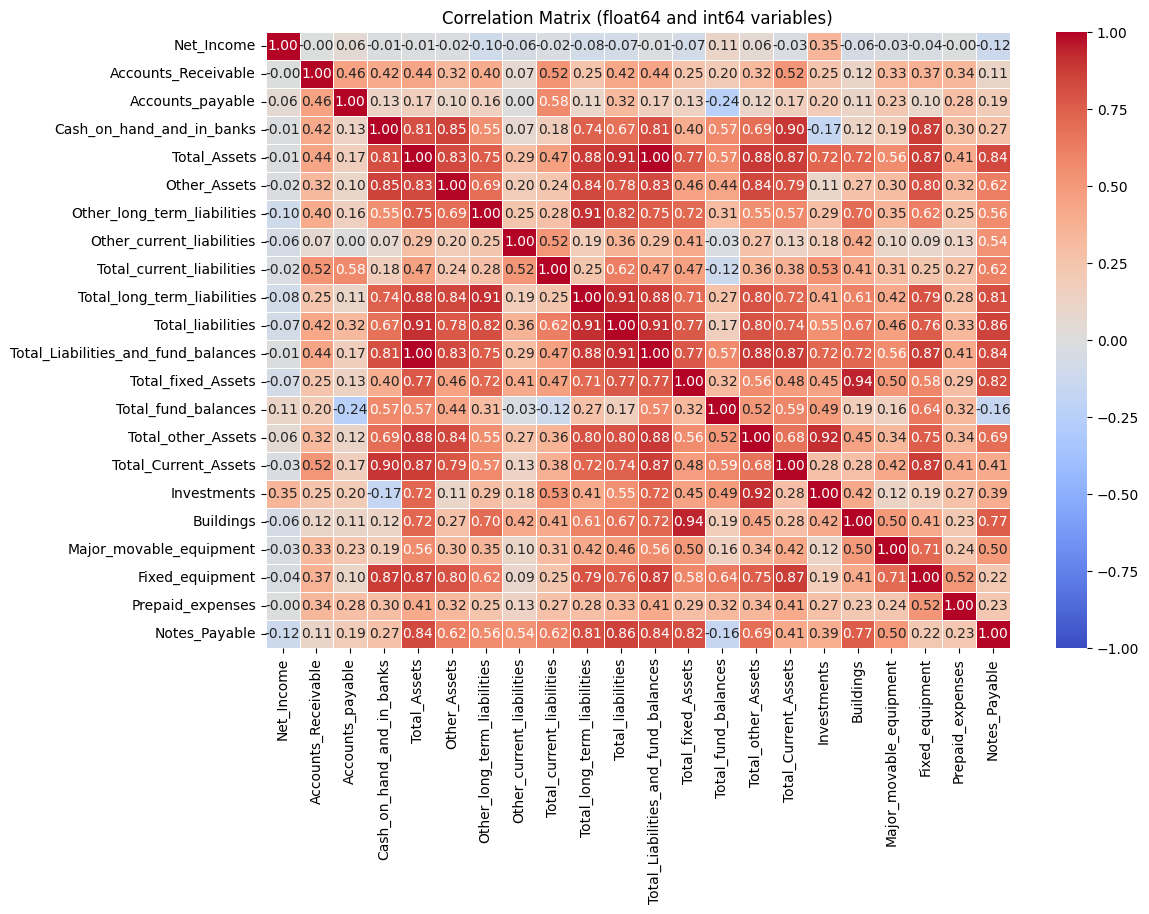

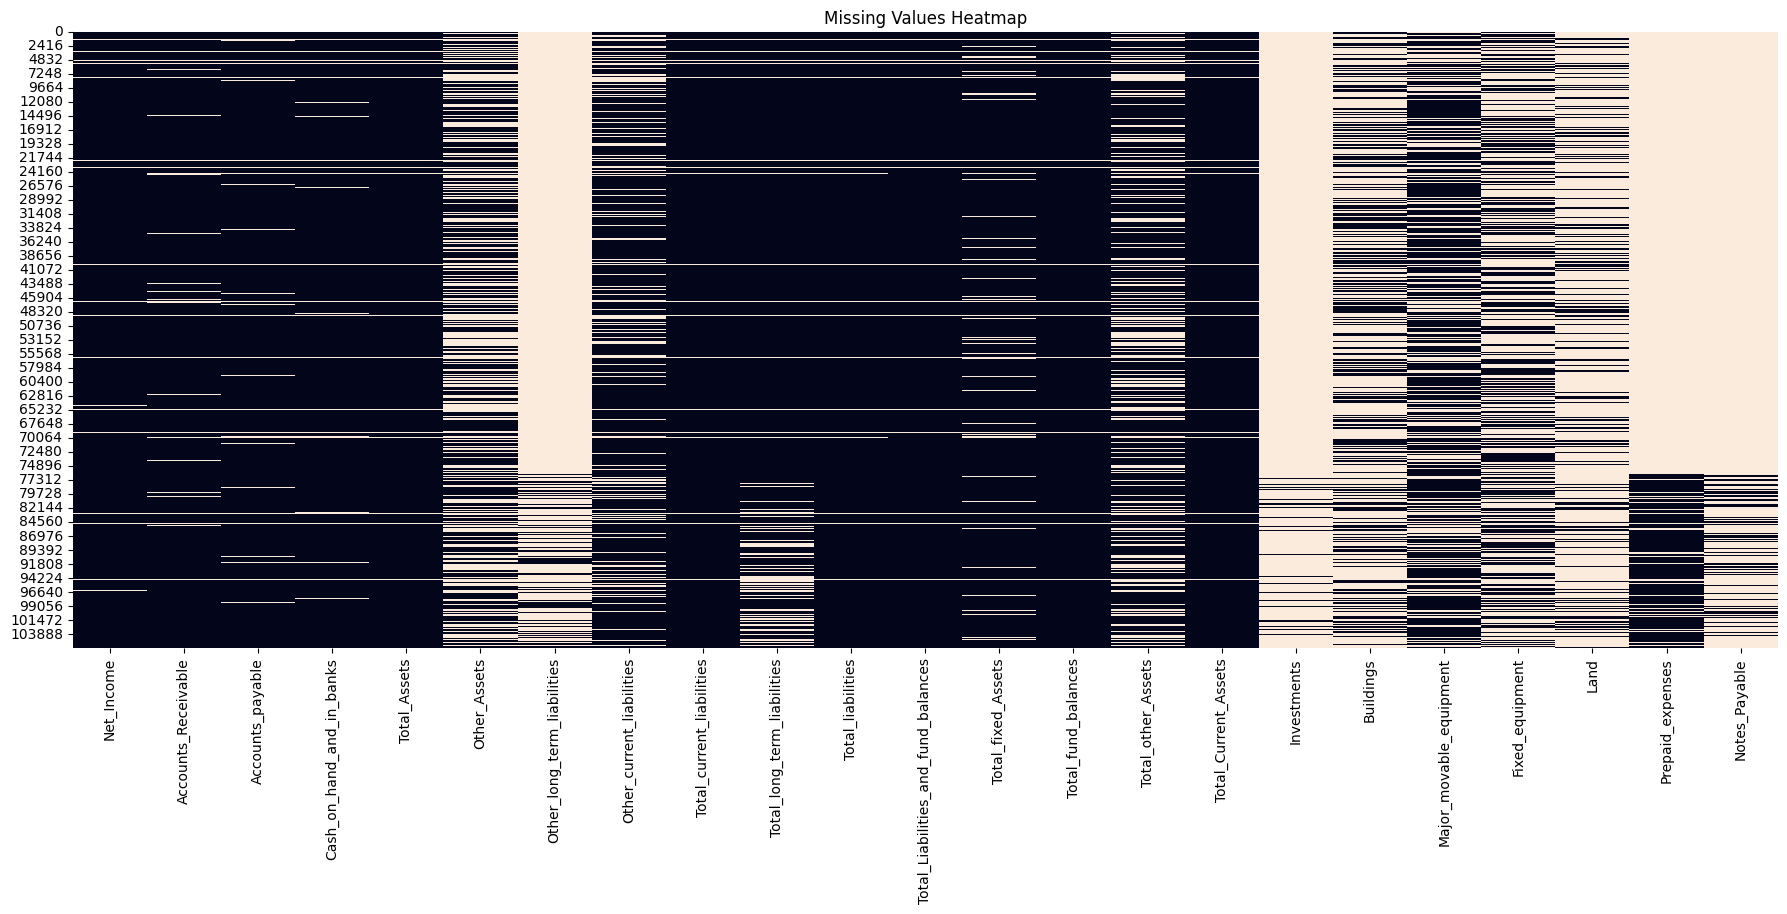

In [46]:
# Select numerical columns (float64 and int64)
num_cols = group_df.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix for the selected columns
corr_matrix = group_df[num_cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix (float64 and int64 variables)")
plt.show()

# Plot the missing values heatmap
plt.figure(figsize=(22, 8))
sns.heatmap(group_df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [47]:
import numpy as np
import pandas as pd

# Compute percentage of missing values for each column
missing_percentage = group_df.isnull().mean() * 100

# Exclude columns with more than 50% missing values
valid_columns = missing_percentage[missing_percentage <= 50].index

# Compute correlation matrix for the filtered numerical columns
corr_matrix = group_df[valid_columns].select_dtypes(include=['float64', 'int64']).corr().abs()

# Identify pairs with high correlation (>= 0.7)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):  # Avoid duplicates
        if corr_matrix.iloc[i, j] >= 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

# Convert list to DataFrame for better visualization
high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Variable_1', 'Variable_2', 'Correlation'])

# Display highly correlated variable pairs
print("Highly Correlated Pairs (|r| ≥ 0.7) excluding variables with >50% missing values:")
high_corr_df


Highly Correlated Pairs (|r| ≥ 0.7) excluding variables with >50% missing values:


,Variable_1,Variable_2,Correlation
0,Cash_on_hand_and_in_banks,Total_Assets,0.806470
1,Cash_on_hand_and_in_banks,Other_Assets,0.853065
2,Cash_on_hand_and_in_banks,Total_long_term_liabilities,0.742506
3,Cash_on_hand_and_in_banks,Total_Liabilities_and_fund_balances,0.806468
4,Cash_on_hand_and_in_banks,Total_Current_Assets,0.896993
5,Total_Assets,Other_Assets,0.833121
6,Total_Assets,Total_long_term_liabilities,0.879282
7,Total_Assets,Total_liabilities,0.907148
8,Total_Assets,Total_Liabilities_and_fund_balances,0.999983
9,Total_Assets,Total_fixed_Assets,0.774405


In [48]:
# Compute correlation of each variable with Net_Income
correlation_with_net_income = corr_matrix["Net_Income"]

# List of variables to drop (the ones with lower correlation with Net_Income)
vars_to_drop = []
net_income_correlations = []  # Store correlations of both variables for reference

for var1, var2, _ in high_corr_pairs:
    cor_var1 = correlation_with_net_income[var1]
    cor_var2 = correlation_with_net_income[var2]

    # Store correlations for reference
    net_income_correlations.append((var1, cor_var1))
    net_income_correlations.append((var2, cor_var2))

    # Drop the variable with the lower absolute correlation with Net_Income
    if abs(cor_var1) < abs(cor_var2):
        vars_to_drop.append(var1)
    else:
        vars_to_drop.append(var2)

# Remove duplicates (in case the same variable appeared multiple times)
vars_to_drop = list(set(vars_to_drop))

# Convert to DataFrame for better visualization
net_income_cor_df = pd.DataFrame(net_income_correlations, columns=["Variable", "Correlation_with_Net_Income"]).drop_duplicates()

# Display variables to be dropped and their correlations
print("Variables to drop due to multicollinearity:")
print(vars_to_drop)

# Display the correlation of all variables involved in multicollinearity with Net_Income
print("\nCorrelation of Multicollinear Variables with Net_Income:")
print(net_income_cor_df)


Variables to drop due to multicollinearity:
['Total_Current_Assets', 'Total_other_Assets', 'Total_Liabilities_and_fund_balances', 'Total_Assets', 'Total_fixed_Assets', 'Other_Assets', 'Cash_on_hand_and_in_banks', 'Total_liabilities']

Correlation of Multicollinear Variables with Net_Income:
                               Variable  Correlation_with_Net_Income
0             Cash_on_hand_and_in_banks                     0.011724
1                          Total_Assets                     0.013971
3                          Other_Assets                     0.022875
5           Total_long_term_liabilities                     0.079302
7   Total_Liabilities_and_fund_balances                     0.011372
9                  Total_Current_Assets                     0.025012
15                    Total_liabilities                     0.074091
19                   Total_fixed_Assets                     0.072134
21                   Total_other_Assets                     0.058940


In [49]:
# Drop the lesser correlated variables
df = df.drop(columns=vars_to_drop)

# Display the cleaned DataFrame
print("Dataset after dropping multicollinear variables:")
df.head()


Dataset after dropping multicollinear variables:


,rpt_rec_num,Provider_CCN,Facility_Name,Street_Address,City,State_Code,Zip_Code,County,Medicare_CBSA_Number,Rural_versus_Urban,Fiscal_Year_Begin_Date,Fiscal_Year_End_Date,Type_of_Control,Accounts_Receivable,Accounts_payable,Buildings,General_fund_balance,Inpatient_PPS_Amount,Inpatient_Revenue,Major_movable_equipment,Net_Income,Net_Patient_Revenue,Number_of_Beds,Other_current_liabilities,Overhead_Non_Salary_Costs,SNF_Admissions_Other,SNF_Admissions_Title_XIX,SNF_Admissions_Title_XVIII,SNF_Admissions_Total,SNF_Days_Other,SNF_Days_Title_XIX,SNF_Days_Title_XVIII,SNF_Days_Total,SNF_Discharges_Title_Other,SNF_Discharges_Title_XIX,SNF_Discharges_Title_XVIII,SNF_Discharges_Total,Salaries_wages_and_fees_payable,Total_Bed_Days_Available,Total_Costs,Total_Days_Other,Total_Days_Title_XIX,Total_Days_Title_XVIII,Total_Days_Total,Total_Discharges_Title_Other,Total_Discharges_Title_XIX,Total_Discharges_Title_XVIII,Total_Discharges_Total,Total_Income,Total_RUG_Days,Total_current_liabilities,Total_fund_balances,Fixed_equipment,Total_Charges,SNF_Number_of_Beds,Total_long_term_liabilities,Investments,Net_Income_from_service_to_patients,Wage-related_Costs_(core),SNF_Average_Length_of_Stay_Total,Notes_Payable,Other_long_term_liabilities,Allowable_Bad_Debts,SNF_Average_Length_of_Stay_Title_XVIII,Total_General_Inpatient_Care_Services_Revenue,SNF_Average_Length_of_Stay_Title_XIX,Outpatient_Revenue,SNF_Bed_Days_Available,Land,Prepaid_expenses,Year
0,1089712,495134,RIDGECREST MANOR NURSING & REHAB CTR,157 ROSS-CARTER BLVD,DUFFIELD,VA,24244,SCOTT,28700.0,U,11/1/2014,12/31/2014,4.0,1366877.0,292277.0,NaN,311430.0,154022.0,1800296.0,59343.0,311430.0,1520630.0,120.0,5667.0,549090.0,2.0,40.0,6.0,48.0,534.0,5853.0,333.0,6720.0,9.0,35.0,5.0,49.0,117929.0,7320.0,211585.0,534.0,5853.0,333.0,6720.0,9.0,35.0,5.0,49.0,311431.0,333.0,453591.0,311430.0,NaN,NaN,120.0,-1.0,NaN,311308.0,80664.0,137.14,NaN,NaN,NaN,66.60,1182049.0,167.23,0.0,NaN,NaN,NaN,2015
1,1091410,75417,REGENCY HEIGHTS OF NORWICH LLC,60 CROUCH AVENUE,NORWICH,CT,6360,NEW LONDON,35980.0,U,10/1/2014,12/14/2014,4.0,1326379.0,NaN,NaN,-4896947.0,393088.0,2843541.0,407352.0,-588469.0,2416825.0,114.0,2596536.0,1886441.0,38.0,NaN,23.0,61.0,7241.0,NaN,856.0,8097.0,36.0,NaN,23.0,59.0,12590.0,8550.0,207903.0,7241.0,NaN,856.0,8097.0,36.0,NaN,23.0,59.0,-588469.0,856.0,2765768.0,-4896947.0,NaN,NaN,114.0,3818635.0,NaN,-588476.0,559430.0,137.24,NaN,NaN,NaN,37.22,2429100.0,NaN,0.0,NaN,NaN,NaN,2015
2,1093283,165252,WESTVIEW ACRES CARE CENTER,203 SW LORRAINE,LEON,IA,50144,DECATUR,99916.0,R,10/1/2014,12/31/2014,4.0,135859.0,79894.0,NaN,52141.0,20234.0,613243.0,NaN,-47859.0,600033.0,60.0,25982.0,290554.0,5.0,4.0,3.0,12.0,956.0,2548.0,71.0,3575.0,3.0,3.0,3.0,9.0,48546.0,5520.0,22920.0,956.0,2548.0,71.0,3575.0,3.0,3.0,3.0,9.0,-30743.0,71.0,192098.0,52141.0,NaN,NaN,60.0,0.0,NaN,-39135.0,42209.0,397.22,NaN,NaN,NaN,23.67,596683.0,849.33,0.0,NaN,NaN,NaN,2015
3,1095547,225497,VERO HEALTH & REHAB PARKWAY,1190 VFW PARKWAY,WEST ROXBURY,MA,2132,SUFFOLK,14454.0,U,11/1/2014,12/31/2014,4.0,1222903.0,537451.0,NaN,6382.0,172528.0,1935277.0,NaN,-63638.0,1378163.0,141.0,97267.0,839217.0,15.0,15.0,9.0,39.0,2883.0,2881.0,349.0,6113.0,13.0,13.0,6.0,32.0,201598.0,8601.0,158386.0,2883.0,2881.0,349.0,6113.0,13.0,13.0,6.0,32.0,-63638.0,349.0,1824376.0,6382.0,NaN,NaN,141.0,0.0,NaN,-66306.0,113676.0,191.03,NaN,NaN,NaN,58.17,1770950.0,221.62,0.0,NaN,NaN,NaN,2015
4,1095966,265161,WILSONS CREEK NURSING & REHAB,3403 WEST MT VERNON,SPRINGFIELD,MO,65802,GREENE,44180.0,U,12/1/2014,12/31/2014,4.0,634347.0,253637.0,NaN,-1613.0,46270.0,818175.0,NaN,-1613.0,769155.0,172.0,50688.0,412154.0,3.0,20.0,3.0,26.0,678.0,3945.0,111.0,4734.0,4.0,24.0,NaN,28.0,258540.0,5332.0,56556.0,678.0,3945.0,111.0,4734.0,4.0,24.0,NaN,28.0,-1613.0,111.0,808822.0,-1613.0,NaN,NaN,172.0,0.0,NaN,-6087.0,99778.0,169.07,NaN,NaN,NaN,NaN,748924.0,164.38,0.0,NaN,NaN,NaN,2015


In [50]:
# Select a specific group
selected_group = "patient_care"  # Change this to switch groups
group_df = df[groups[selected_group]]

# Display the first few rows
group_df.head()

,Net_Income,Inpatient_PPS_Amount,Inpatient_Revenue,SNF_Admissions_Other,SNF_Admissions_Title_XIX,SNF_Admissions_Title_XVIII,SNF_Admissions_Total,SNF_Days_Other,SNF_Days_Title_XIX,SNF_Days_Title_XVIII,SNF_Days_Total,SNF_Discharges_Title_Other,SNF_Discharges_Title_XIX,SNF_Discharges_Title_XVIII,SNF_Discharges_Total,Total_General_Inpatient_Care_Services_Revenue
0,311430.0,154022.0,1800296.0,2.0,40.0,6.0,48.0,534.0,5853.0,333.0,6720.0,9.0,35.0,5.0,49.0,1182049.0
1,-588469.0,393088.0,2843541.0,38.0,NaN,23.0,61.0,7241.0,NaN,856.0,8097.0,36.0,NaN,23.0,59.0,2429100.0
2,-47859.0,20234.0,613243.0,5.0,4.0,3.0,12.0,956.0,2548.0,71.0,3575.0,3.0,3.0,3.0,9.0,596683.0
3,-63638.0,172528.0,1935277.0,15.0,15.0,9.0,39.0,2883.0,2881.0,349.0,6113.0,13.0,13.0,6.0,32.0,1770950.0
4,-1613.0,46270.0,818175.0,3.0,20.0,3.0,26.0,678.0,3945.0,111.0,4734.0,4.0,24.0,NaN,28.0,748924.0


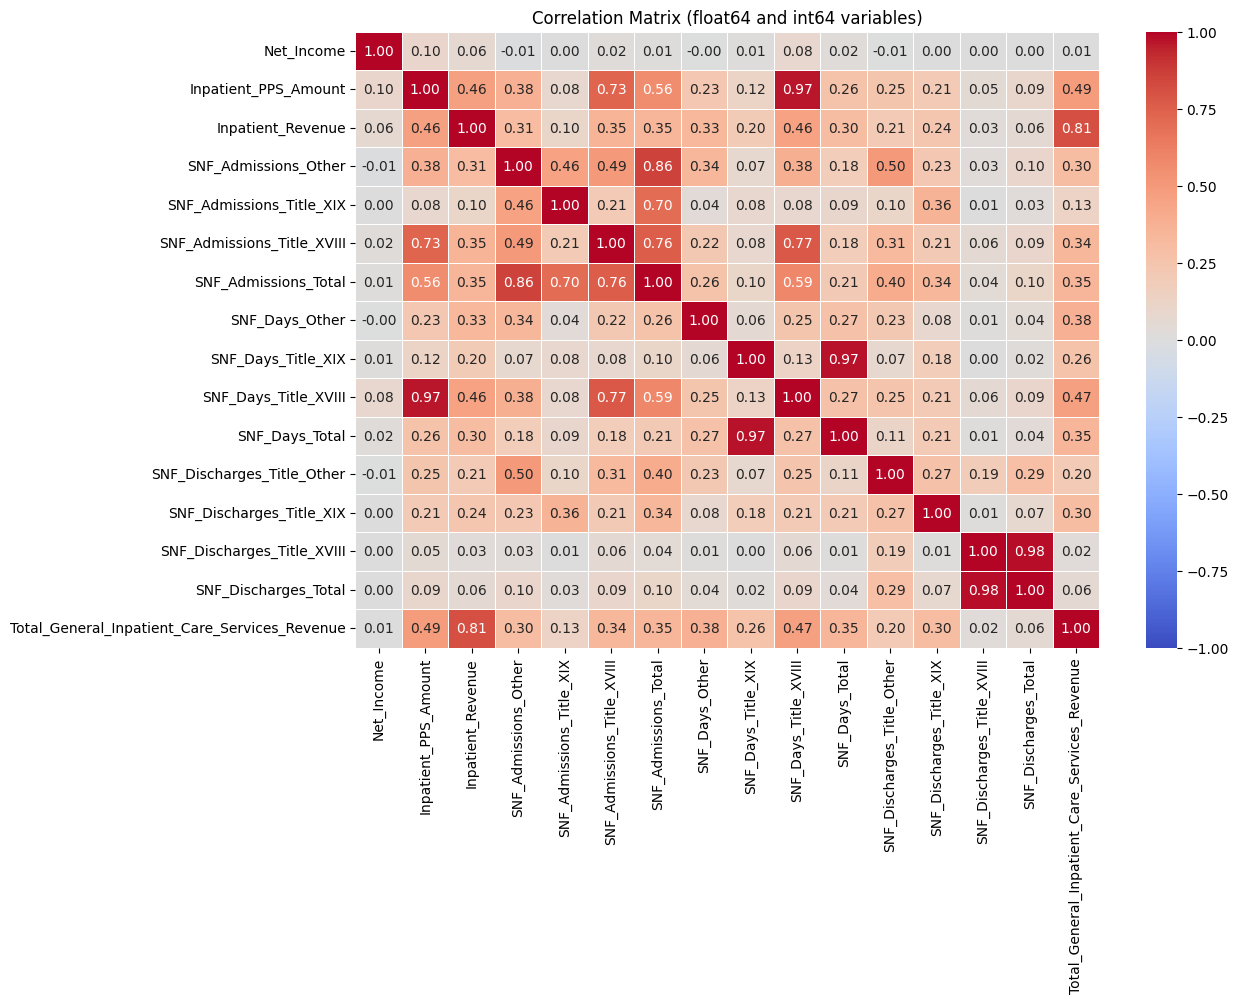

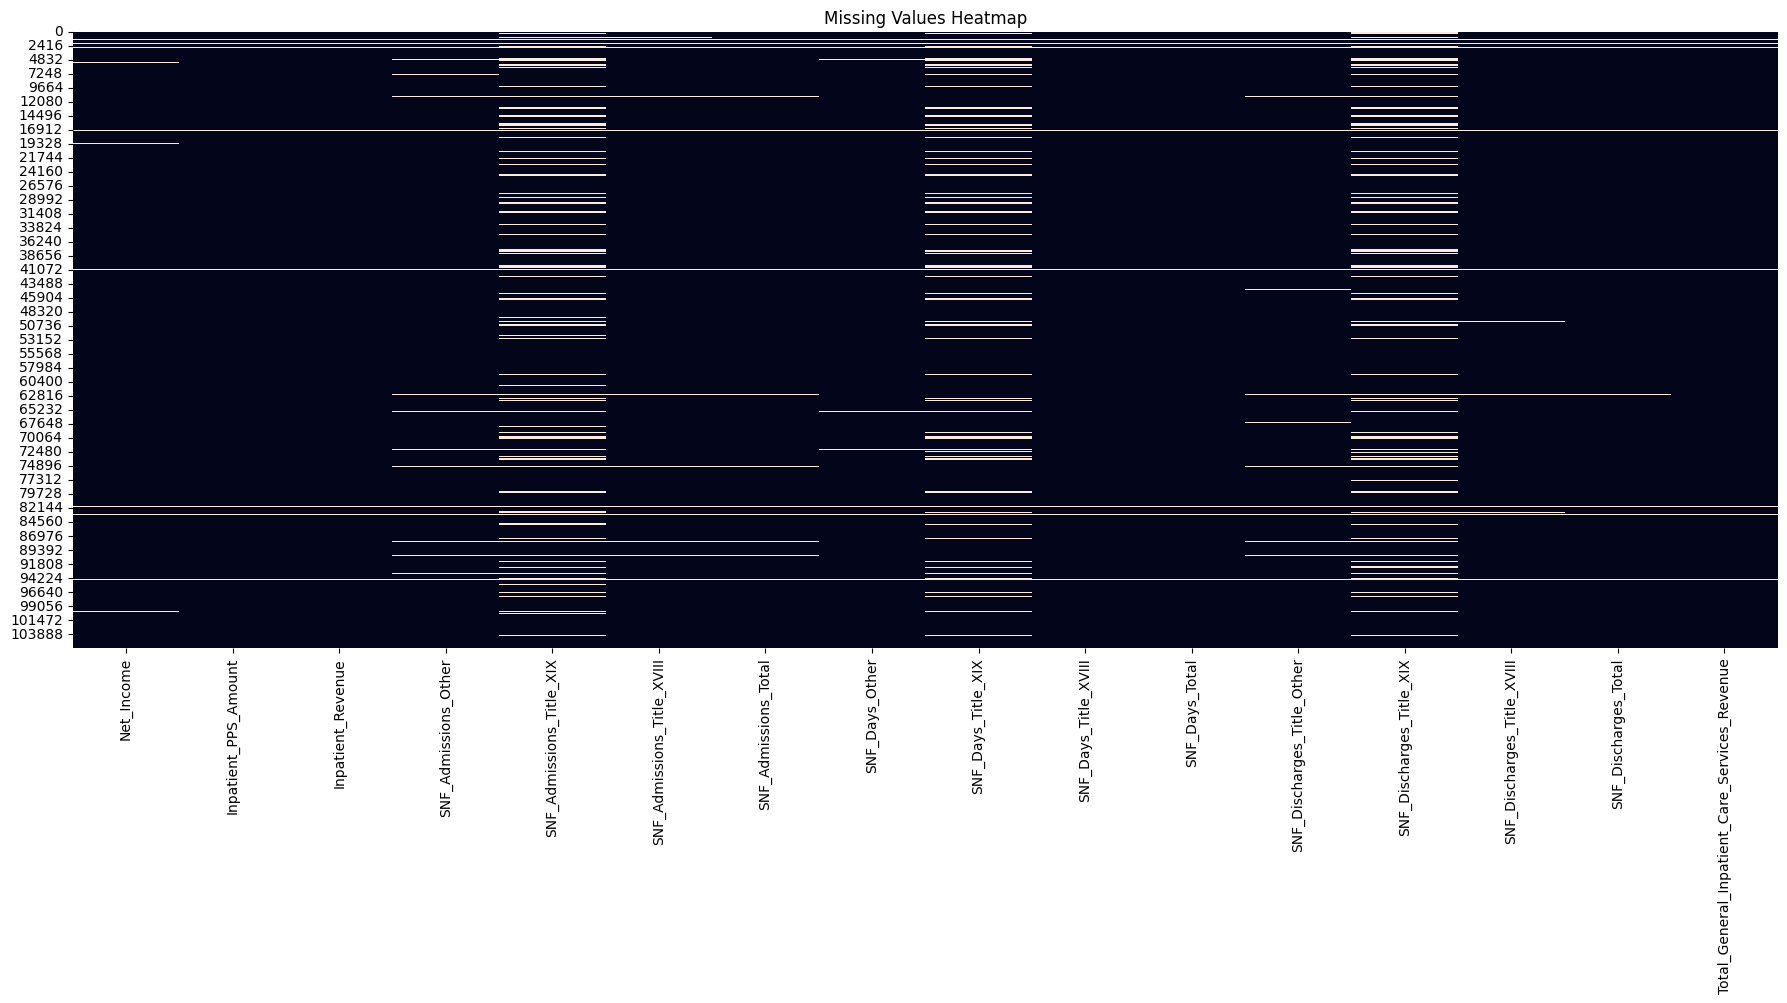

In [51]:
# Select numerical columns (float64 and int64)
num_cols = group_df.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix for the selected columns
corr_matrix = group_df[num_cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix (float64 and int64 variables)")
plt.show()

# Plot the missing values heatmap
plt.figure(figsize=(22, 8))
sns.heatmap(group_df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [52]:
import numpy as np
import pandas as pd

# Compute percentage of missing values for each column
missing_percentage = group_df.isnull().mean() * 100

# Exclude columns with more than 50% missing values
valid_columns = missing_percentage[missing_percentage <= 50].index

# Compute correlation matrix for the filtered numerical columns
corr_matrix = group_df[valid_columns].select_dtypes(include=['float64', 'int64']).corr().abs()

# Identify pairs with high correlation (>= 0.7)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):  # Avoid duplicates
        if corr_matrix.iloc[i, j] >= 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

# Convert list to DataFrame for better visualization
high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Variable_1', 'Variable_2', 'Correlation'])

# Display highly correlated variable pairs
print("Highly Correlated Pairs (|r| ≥ 0.7) excluding variables with >50% missing values:")
high_corr_df


Highly Correlated Pairs (|r| ≥ 0.7) excluding variables with >50% missing values:


,Variable_1,Variable_2,Correlation
0,Inpatient_PPS_Amount,SNF_Admissions_Title_XVIII,0.730029
1,Inpatient_PPS_Amount,SNF_Days_Title_XVIII,0.968058
2,Inpatient_Revenue,Total_General_Inpatient_Care_Services_Revenue,0.810123
3,SNF_Admissions_Other,SNF_Admissions_Total,0.855928
4,SNF_Admissions_Title_XVIII,SNF_Admissions_Total,0.759541
5,SNF_Admissions_Title_XVIII,SNF_Days_Title_XVIII,0.774195
6,SNF_Days_Title_XIX,SNF_Days_Total,0.969637
7,SNF_Discharges_Title_XVIII,SNF_Discharges_Total,0.978397


In [53]:
# Compute correlation of each variable with Net_Income
correlation_with_net_income = corr_matrix["Net_Income"]

# List of variables to drop (the ones with lower correlation with Net_Income)
vars_to_drop = []
net_income_correlations = []  # Store correlations of both variables for reference

for var1, var2, _ in high_corr_pairs:
    cor_var1 = correlation_with_net_income[var1]
    cor_var2 = correlation_with_net_income[var2]

    # Store correlations for reference
    net_income_correlations.append((var1, cor_var1))
    net_income_correlations.append((var2, cor_var2))

    # Drop the variable with the lower absolute correlation with Net_Income
    if abs(cor_var1) < abs(cor_var2):
        vars_to_drop.append(var1)
    else:
        vars_to_drop.append(var2)

# Remove duplicates (in case the same variable appeared multiple times)
vars_to_drop = list(set(vars_to_drop))

# Convert to DataFrame for better visualization
net_income_cor_df = pd.DataFrame(net_income_correlations, columns=["Variable", "Correlation_with_Net_Income"]).drop_duplicates()

# Display variables to be dropped and their correlations
print("Variables to drop due to multicollinearity:")
print(vars_to_drop)

# Display the correlation of all variables involved in multicollinearity with Net_Income
print("\nCorrelation of Multicollinear Variables with Net_Income:")
print(net_income_cor_df)


Variables to drop due to multicollinearity:
['SNF_Admissions_Other', 'SNF_Days_Title_XIX', 'Total_General_Inpatient_Care_Services_Revenue', 'SNF_Discharges_Total', 'SNF_Admissions_Total', 'SNF_Admissions_Title_XVIII', 'SNF_Days_Title_XVIII']

Correlation of Multicollinear Variables with Net_Income:
                                         Variable  Correlation_with_Net_Income
0                            Inpatient_PPS_Amount                     0.098583
1                      SNF_Admissions_Title_XVIII                     0.022840
3                            SNF_Days_Title_XVIII                     0.079900
4                               Inpatient_Revenue                     0.063507
5   Total_General_Inpatient_Care_Services_Revenue                     0.005894
6                            SNF_Admissions_Other                     0.008098
7                            SNF_Admissions_Total                     0.010759
12                             SNF_Days_Title_XIX                   

In [54]:
# Drop the lesser correlated variables
df = df.drop(columns=vars_to_drop)

# Display the cleaned DataFrame
print("Dataset after dropping multicollinear variables:")
df.head()

Dataset after dropping multicollinear variables:


,rpt_rec_num,Provider_CCN,Facility_Name,Street_Address,City,State_Code,Zip_Code,County,Medicare_CBSA_Number,Rural_versus_Urban,Fiscal_Year_Begin_Date,Fiscal_Year_End_Date,Type_of_Control,Accounts_Receivable,Accounts_payable,Buildings,General_fund_balance,Inpatient_PPS_Amount,Inpatient_Revenue,Major_movable_equipment,Net_Income,Net_Patient_Revenue,Number_of_Beds,Other_current_liabilities,Overhead_Non_Salary_Costs,SNF_Admissions_Title_XIX,SNF_Days_Other,SNF_Days_Total,SNF_Discharges_Title_Other,SNF_Discharges_Title_XIX,SNF_Discharges_Title_XVIII,Salaries_wages_and_fees_payable,Total_Bed_Days_Available,Total_Costs,Total_Days_Other,Total_Days_Title_XIX,Total_Days_Title_XVIII,Total_Days_Total,Total_Discharges_Title_Other,Total_Discharges_Title_XIX,Total_Discharges_Title_XVIII,Total_Discharges_Total,Total_Income,Total_RUG_Days,Total_current_liabilities,Total_fund_balances,Fixed_equipment,Total_Charges,SNF_Number_of_Beds,Total_long_term_liabilities,Investments,Net_Income_from_service_to_patients,Wage-related_Costs_(core),SNF_Average_Length_of_Stay_Total,Notes_Payable,Other_long_term_liabilities,Allowable_Bad_Debts,SNF_Average_Length_of_Stay_Title_XVIII,SNF_Average_Length_of_Stay_Title_XIX,Outpatient_Revenue,SNF_Bed_Days_Available,Land,Prepaid_expenses,Year
0,1089712,495134,RIDGECREST MANOR NURSING & REHAB CTR,157 ROSS-CARTER BLVD,DUFFIELD,VA,24244,SCOTT,28700.0,U,11/1/2014,12/31/2014,4.0,1366877.0,292277.0,NaN,311430.0,154022.0,1800296.0,59343.0,311430.0,1520630.0,120.0,5667.0,549090.0,40.0,534.0,6720.0,9.0,35.0,5.0,117929.0,7320.0,211585.0,534.0,5853.0,333.0,6720.0,9.0,35.0,5.0,49.0,311431.0,333.0,453591.0,311430.0,NaN,NaN,120.0,-1.0,NaN,311308.0,80664.0,137.14,NaN,NaN,NaN,66.60,167.23,0.0,NaN,NaN,NaN,2015
1,1091410,75417,REGENCY HEIGHTS OF NORWICH LLC,60 CROUCH AVENUE,NORWICH,CT,6360,NEW LONDON,35980.0,U,10/1/2014,12/14/2014,4.0,1326379.0,NaN,NaN,-4896947.0,393088.0,2843541.0,407352.0,-588469.0,2416825.0,114.0,2596536.0,1886441.0,NaN,7241.0,8097.0,36.0,NaN,23.0,12590.0,8550.0,207903.0,7241.0,NaN,856.0,8097.0,36.0,NaN,23.0,59.0,-588469.0,856.0,2765768.0,-4896947.0,NaN,NaN,114.0,3818635.0,NaN,-588476.0,559430.0,137.24,NaN,NaN,NaN,37.22,NaN,0.0,NaN,NaN,NaN,2015
2,1093283,165252,WESTVIEW ACRES CARE CENTER,203 SW LORRAINE,LEON,IA,50144,DECATUR,99916.0,R,10/1/2014,12/31/2014,4.0,135859.0,79894.0,NaN,52141.0,20234.0,613243.0,NaN,-47859.0,600033.0,60.0,25982.0,290554.0,4.0,956.0,3575.0,3.0,3.0,3.0,48546.0,5520.0,22920.0,956.0,2548.0,71.0,3575.0,3.0,3.0,3.0,9.0,-30743.0,71.0,192098.0,52141.0,NaN,NaN,60.0,0.0,NaN,-39135.0,42209.0,397.22,NaN,NaN,NaN,23.67,849.33,0.0,NaN,NaN,NaN,2015
3,1095547,225497,VERO HEALTH & REHAB PARKWAY,1190 VFW PARKWAY,WEST ROXBURY,MA,2132,SUFFOLK,14454.0,U,11/1/2014,12/31/2014,4.0,1222903.0,537451.0,NaN,6382.0,172528.0,1935277.0,NaN,-63638.0,1378163.0,141.0,97267.0,839217.0,15.0,2883.0,6113.0,13.0,13.0,6.0,201598.0,8601.0,158386.0,2883.0,2881.0,349.0,6113.0,13.0,13.0,6.0,32.0,-63638.0,349.0,1824376.0,6382.0,NaN,NaN,141.0,0.0,NaN,-66306.0,113676.0,191.03,NaN,NaN,NaN,58.17,221.62,0.0,NaN,NaN,NaN,2015
4,1095966,265161,WILSONS CREEK NURSING & REHAB,3403 WEST MT VERNON,SPRINGFIELD,MO,65802,GREENE,44180.0,U,12/1/2014,12/31/2014,4.0,634347.0,253637.0,NaN,-1613.0,46270.0,818175.0,NaN,-1613.0,769155.0,172.0,50688.0,412154.0,20.0,678.0,4734.0,4.0,24.0,NaN,258540.0,5332.0,56556.0,678.0,3945.0,111.0,4734.0,4.0,24.0,NaN,28.0,-1613.0,111.0,808822.0,-1613.0,NaN,NaN,172.0,0.0,NaN,-6087.0,99778.0,169.07,NaN,NaN,NaN,NaN,164.38,0.0,NaN,NaN,NaN,2015


In [55]:
# Select a specific group
selected_group = "facility_operations"  # Change this to switch groups
group_df = df[groups[selected_group]]

# Display the first few rows
group_df.head()

,Net_Income,rpt_rec_num,Provider_CCN,Facility_Name,Street_Address,City,State_Code,Zip_Code,County,Medicare_CBSA_Number,Rural_versus_Urban,Fiscal_Year_Begin_Date,Fiscal_Year_End_Date,Type_of_Control,Total_Bed_Days_Available,Total_Days_Other,Total_Days_Title_XIX,Total_Days_Title_XVIII,Total_Days_Total,Total_Discharges_Title_Other,Total_Discharges_Title_XIX,Total_Discharges_Title_XVIII,Total_Discharges_Total,Total_RUG_Days,Total_Costs,SNF_Number_of_Beds,SNF_Average_Length_of_Stay_Total,SNF_Average_Length_of_Stay_Title_XVIII,SNF_Average_Length_of_Stay_Title_XIX,SNF_Bed_Days_Available,Year
0,311430.0,1089712,495134,RIDGECREST MANOR NURSING & REHAB CTR,157 ROSS-CARTER BLVD,DUFFIELD,VA,24244,SCOTT,28700.0,U,11/1/2014,12/31/2014,4.0,7320.0,534.0,5853.0,333.0,6720.0,9.0,35.0,5.0,49.0,333.0,211585.0,120.0,137.14,66.60,167.23,NaN,2015
1,-588469.0,1091410,75417,REGENCY HEIGHTS OF NORWICH LLC,60 CROUCH AVENUE,NORWICH,CT,6360,NEW LONDON,35980.0,U,10/1/2014,12/14/2014,4.0,8550.0,7241.0,NaN,856.0,8097.0,36.0,NaN,23.0,59.0,856.0,207903.0,114.0,137.24,37.22,NaN,NaN,2015
2,-47859.0,1093283,165252,WESTVIEW ACRES CARE CENTER,203 SW LORRAINE,LEON,IA,50144,DECATUR,99916.0,R,10/1/2014,12/31/2014,4.0,5520.0,956.0,2548.0,71.0,3575.0,3.0,3.0,3.0,9.0,71.0,22920.0,60.0,397.22,23.67,849.33,NaN,2015
3,-63638.0,1095547,225497,VERO HEALTH & REHAB PARKWAY,1190 VFW PARKWAY,WEST ROXBURY,MA,2132,SUFFOLK,14454.0,U,11/1/2014,12/31/2014,4.0,8601.0,2883.0,2881.0,349.0,6113.0,13.0,13.0,6.0,32.0,349.0,158386.0,141.0,191.03,58.17,221.62,NaN,2015
4,-1613.0,1095966,265161,WILSONS CREEK NURSING & REHAB,3403 WEST MT VERNON,SPRINGFIELD,MO,65802,GREENE,44180.0,U,12/1/2014,12/31/2014,4.0,5332.0,678.0,3945.0,111.0,4734.0,4.0,24.0,NaN,28.0,111.0,56556.0,172.0,169.07,NaN,164.38,NaN,2015


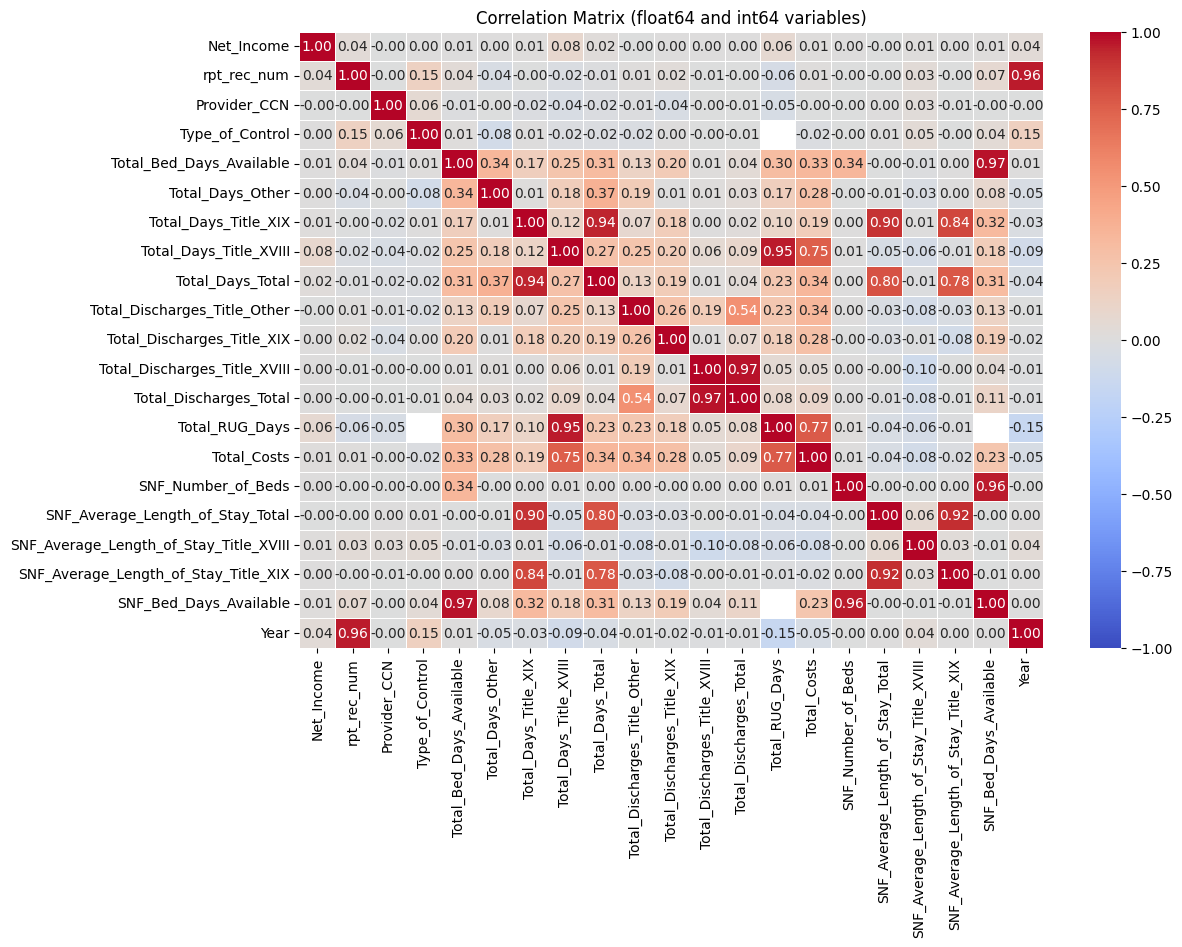

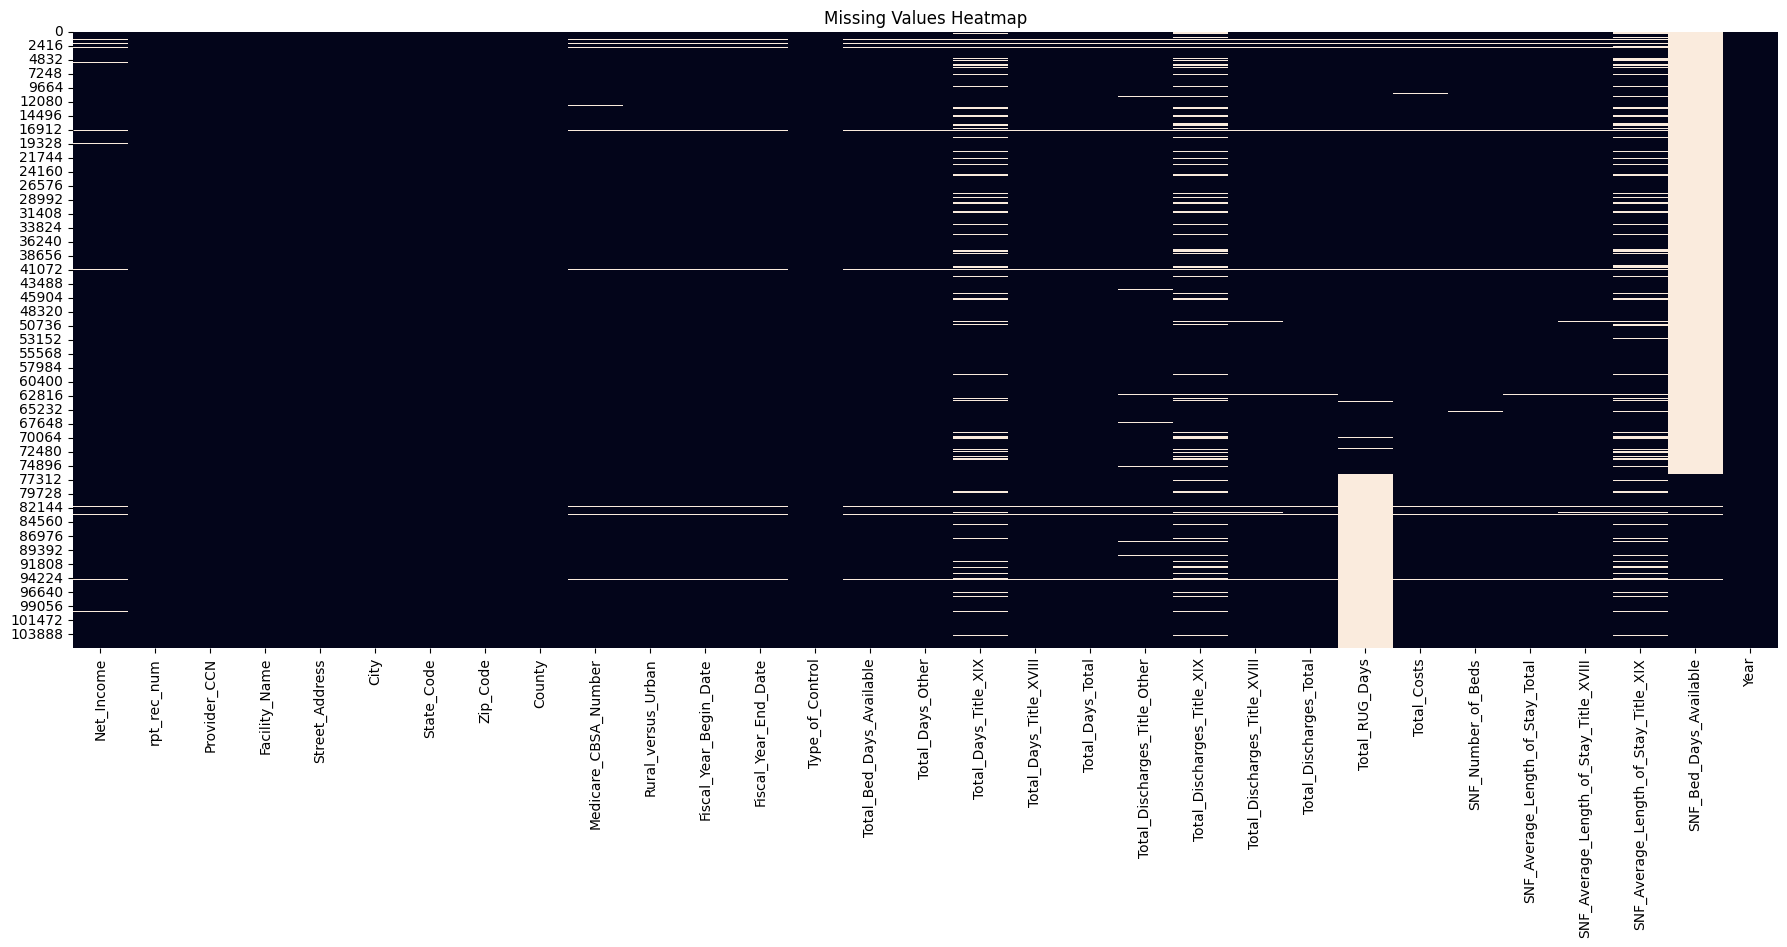

In [56]:
# Select numerical columns (float64 and int64)
num_cols = group_df.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix for the selected columns
corr_matrix = group_df[num_cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix (float64 and int64 variables)")
plt.show()

# Plot the missing values heatmap
plt.figure(figsize=(22, 8))
sns.heatmap(group_df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [57]:
import numpy as np
import pandas as pd

# Compute percentage of missing values for each column
missing_percentage = group_df.isnull().mean() * 100

# Exclude columns with more than 50% missing values
valid_columns = missing_percentage[missing_percentage <= 50].index

# Compute correlation matrix for the filtered numerical columns
corr_matrix = group_df[valid_columns].select_dtypes(include=['float64', 'int64']).corr().abs()

# Identify pairs with high correlation (>= 0.7)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):  # Avoid duplicates
        if corr_matrix.iloc[i, j] >= 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

# Convert list to DataFrame for better visualization
high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Variable_1', 'Variable_2', 'Correlation'])

# Display highly correlated variable pairs
print("Highly Correlated Pairs (|r| ≥ 0.7) excluding variables with >50% missing values:")
high_corr_df


Highly Correlated Pairs (|r| ≥ 0.7) excluding variables with >50% missing values:


,Variable_1,Variable_2,Correlation
0,rpt_rec_num,Year,0.959063
1,Total_Days_Title_XIX,Total_Days_Total,0.941090
2,Total_Days_Title_XIX,SNF_Average_Length_of_Stay_Total,0.902536
3,Total_Days_Title_XIX,SNF_Average_Length_of_Stay_Title_XIX,0.836504
4,Total_Days_Title_XVIII,Total_RUG_Days,0.953294
5,Total_Days_Title_XVIII,Total_Costs,0.751914
6,Total_Days_Total,SNF_Average_Length_of_Stay_Total,0.799797
7,Total_Days_Total,SNF_Average_Length_of_Stay_Title_XIX,0.775909
8,Total_Discharges_Title_XVIII,Total_Discharges_Total,0.972406
9,Total_RUG_Days,Total_Costs,0.773068


In [58]:
# Compute correlation of each variable with Net_Income
correlation_with_net_income = corr_matrix["Net_Income"]

# List of variables to drop (the ones with lower correlation with Net_Income)
vars_to_drop = []
net_income_correlations = []  # Store correlations of both variables for reference

for var1, var2, _ in high_corr_pairs:
    cor_var1 = correlation_with_net_income[var1]
    cor_var2 = correlation_with_net_income[var2]

    # Store correlations for reference
    net_income_correlations.append((var1, cor_var1))
    net_income_correlations.append((var2, cor_var2))

    # Drop the variable with the lower absolute correlation with Net_Income
    if abs(cor_var1) < abs(cor_var2):
        vars_to_drop.append(var1)
    else:
        vars_to_drop.append(var2)

# Remove duplicates (in case the same variable appeared multiple times)
vars_to_drop = list(set(vars_to_drop))

# Convert to DataFrame for better visualization
net_income_cor_df = pd.DataFrame(net_income_correlations, columns=["Variable", "Correlation_with_Net_Income"]).drop_duplicates()

# Display variables to be dropped and their correlations
print("Variables to drop due to multicollinearity:")
print(vars_to_drop)

# Display the correlation of all variables involved in multicollinearity with Net_Income
print("\nCorrelation of Multicollinear Variables with Net_Income:")
print(net_income_cor_df)


Variables to drop due to multicollinearity:
['SNF_Average_Length_of_Stay_Total', 'Total_Days_Title_XIX', 'Total_Costs', 'SNF_Average_Length_of_Stay_Title_XIX', 'Total_Discharges_Total', 'Total_RUG_Days', 'Year']

Correlation of Multicollinear Variables with Net_Income:
                                Variable  Correlation_with_Net_Income
0                            rpt_rec_num                     0.038690
1                                   Year                     0.038141
2                   Total_Days_Title_XIX                     0.008586
3                       Total_Days_Total                     0.020810
5       SNF_Average_Length_of_Stay_Total                     0.001523
7   SNF_Average_Length_of_Stay_Title_XIX                     0.002720
8                 Total_Days_Title_XVIII                     0.078339
9                         Total_RUG_Days                     0.064976
11                           Total_Costs                     0.009380
16          Total_Discharges_T

In [59]:
# Drop the lesser correlated variables
df = df.drop(columns=vars_to_drop)

# Display the cleaned DataFrame
print("Dataset after dropping multicollinear variables:")
df.head()

Dataset after dropping multicollinear variables:


,rpt_rec_num,Provider_CCN,Facility_Name,Street_Address,City,State_Code,Zip_Code,County,Medicare_CBSA_Number,Rural_versus_Urban,Fiscal_Year_Begin_Date,Fiscal_Year_End_Date,Type_of_Control,Accounts_Receivable,Accounts_payable,Buildings,General_fund_balance,Inpatient_PPS_Amount,Inpatient_Revenue,Major_movable_equipment,Net_Income,Net_Patient_Revenue,Number_of_Beds,Other_current_liabilities,Overhead_Non_Salary_Costs,SNF_Admissions_Title_XIX,SNF_Days_Other,SNF_Days_Total,SNF_Discharges_Title_Other,SNF_Discharges_Title_XIX,SNF_Discharges_Title_XVIII,Salaries_wages_and_fees_payable,Total_Bed_Days_Available,Total_Days_Other,Total_Days_Title_XVIII,Total_Days_Total,Total_Discharges_Title_Other,Total_Discharges_Title_XIX,Total_Discharges_Title_XVIII,Total_Income,Total_current_liabilities,Total_fund_balances,Fixed_equipment,Total_Charges,SNF_Number_of_Beds,Total_long_term_liabilities,Investments,Net_Income_from_service_to_patients,Wage-related_Costs_(core),Notes_Payable,Other_long_term_liabilities,Allowable_Bad_Debts,SNF_Average_Length_of_Stay_Title_XVIII,Outpatient_Revenue,SNF_Bed_Days_Available,Land,Prepaid_expenses
0,1089712,495134,RIDGECREST MANOR NURSING & REHAB CTR,157 ROSS-CARTER BLVD,DUFFIELD,VA,24244,SCOTT,28700.0,U,11/1/2014,12/31/2014,4.0,1366877.0,292277.0,NaN,311430.0,154022.0,1800296.0,59343.0,311430.0,1520630.0,120.0,5667.0,549090.0,40.0,534.0,6720.0,9.0,35.0,5.0,117929.0,7320.0,534.0,333.0,6720.0,9.0,35.0,5.0,311431.0,453591.0,311430.0,NaN,NaN,120.0,-1.0,NaN,311308.0,80664.0,NaN,NaN,NaN,66.60,0.0,NaN,NaN,NaN
1,1091410,75417,REGENCY HEIGHTS OF NORWICH LLC,60 CROUCH AVENUE,NORWICH,CT,6360,NEW LONDON,35980.0,U,10/1/2014,12/14/2014,4.0,1326379.0,NaN,NaN,-4896947.0,393088.0,2843541.0,407352.0,-588469.0,2416825.0,114.0,2596536.0,1886441.0,NaN,7241.0,8097.0,36.0,NaN,23.0,12590.0,8550.0,7241.0,856.0,8097.0,36.0,NaN,23.0,-588469.0,2765768.0,-4896947.0,NaN,NaN,114.0,3818635.0,NaN,-588476.0,559430.0,NaN,NaN,NaN,37.22,0.0,NaN,NaN,NaN
2,1093283,165252,WESTVIEW ACRES CARE CENTER,203 SW LORRAINE,LEON,IA,50144,DECATUR,99916.0,R,10/1/2014,12/31/2014,4.0,135859.0,79894.0,NaN,52141.0,20234.0,613243.0,NaN,-47859.0,600033.0,60.0,25982.0,290554.0,4.0,956.0,3575.0,3.0,3.0,3.0,48546.0,5520.0,956.0,71.0,3575.0,3.0,3.0,3.0,-30743.0,192098.0,52141.0,NaN,NaN,60.0,0.0,NaN,-39135.0,42209.0,NaN,NaN,NaN,23.67,0.0,NaN,NaN,NaN
3,1095547,225497,VERO HEALTH & REHAB PARKWAY,1190 VFW PARKWAY,WEST ROXBURY,MA,2132,SUFFOLK,14454.0,U,11/1/2014,12/31/2014,4.0,1222903.0,537451.0,NaN,6382.0,172528.0,1935277.0,NaN,-63638.0,1378163.0,141.0,97267.0,839217.0,15.0,2883.0,6113.0,13.0,13.0,6.0,201598.0,8601.0,2883.0,349.0,6113.0,13.0,13.0,6.0,-63638.0,1824376.0,6382.0,NaN,NaN,141.0,0.0,NaN,-66306.0,113676.0,NaN,NaN,NaN,58.17,0.0,NaN,NaN,NaN
4,1095966,265161,WILSONS CREEK NURSING & REHAB,3403 WEST MT VERNON,SPRINGFIELD,MO,65802,GREENE,44180.0,U,12/1/2014,12/31/2014,4.0,634347.0,253637.0,NaN,-1613.0,46270.0,818175.0,NaN,-1613.0,769155.0,172.0,50688.0,412154.0,20.0,678.0,4734.0,4.0,24.0,NaN,258540.0,5332.0,678.0,111.0,4734.0,4.0,24.0,NaN,-1613.0,808822.0,-1613.0,NaN,NaN,172.0,0.0,NaN,-6087.0,99778.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN


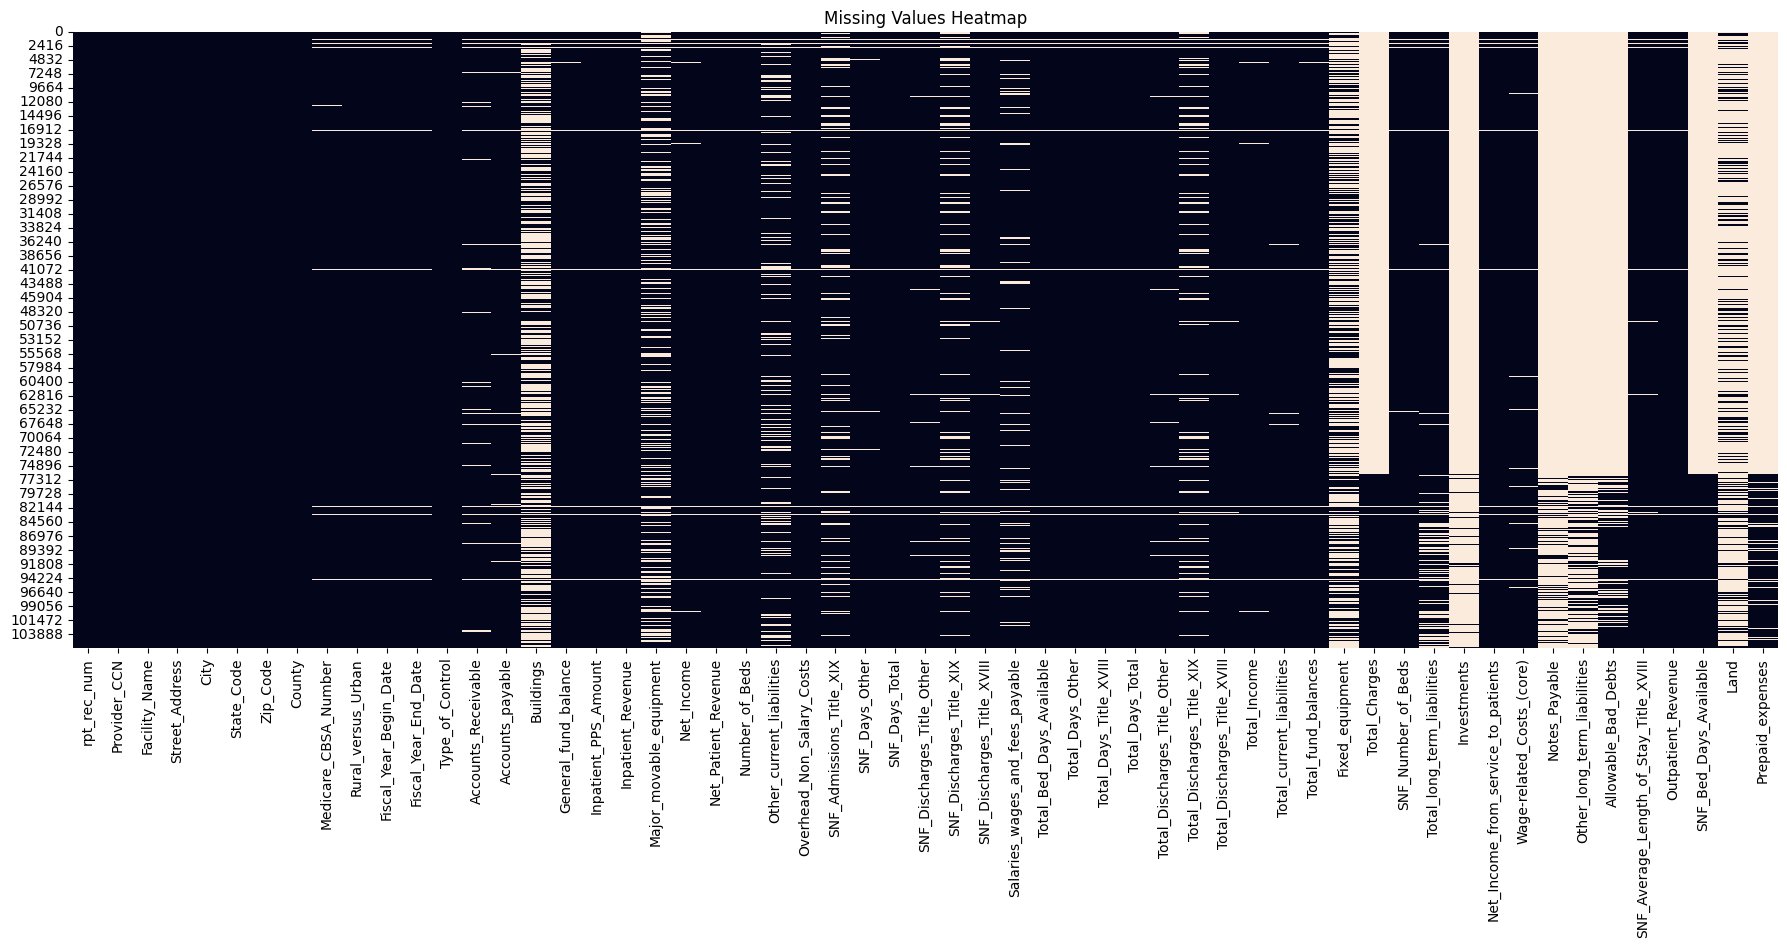

In [60]:
# Plot the missing values heatmap
plt.figure(figsize=(22, 8))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

This dataset is pretty solid. There shouldn't be any bad multicollinearity. These are important variables. The only thing is that 7 are missing a lot of values. So I will focus to find a way to fill these in using formulas and educated averages. If I can I will keep them in.

In [61]:
# Count the total number of columns in df
num_columns = df.shape[1]

# Display the count
print(f"Total number of variables in df: {num_columns}")


Total number of variables in df: 57


In [62]:
# Calculate percentage of missing values for each column
missing_percentage = df.isnull().mean() * 100

# Select columns with more than 50% missing values
high_na_columns = missing_percentage[missing_percentage > 50].index.tolist()

# Display the columns
print("Columns with more than 50% missing values:")
print(high_na_columns)


Columns with more than 50% missing values:
['Buildings', 'Fixed_equipment', 'Total_Charges', 'Investments', 'Notes_Payable', 'Other_long_term_liabilities', 'Allowable_Bad_Debts', 'SNF_Bed_Days_Available', 'Land', 'Prepaid_expenses']


### Limitations
1. I have 10 variables that include a lot of NULLS. 
2. I dropped the columns that were 50% or more NA based on correlation but in groups. The groups were based on related words in the variable. I could've seperated it a different way statistically. 
3. I dropped the rest of the columns based on if they have multicollinearity within groups of columns. I seperated them into 4 groups using AI. And I dropped the multicollinearity columns with lesser of a correlation to Net_Income. 
4. We went from 90+ columns to 56.
5. It doesn't account for string variables. And I keep dates

In [63]:
# Export df_Cost to a CSV file
df.to_csv('df_filled_important_multicol.csv', index=False)
# then move it to the dataset folder

I will make another dataset. I want to make one that drops all the 10 variables that include 50% or more NAs. 

In [64]:
# Calculate the percentage of missing values for each column
missing_percentage = df.isnull().mean() * 100

# Identify columns with more than 50% missing values
cols_to_drop = missing_percentage[missing_percentage > 50].index

# Drop the identified columns
df_cleaned = df.drop(columns=cols_to_drop)

# Display the columns that were dropped
print(f"Columns dropped due to >50% missing values: {list(cols_to_drop)}")

# Optionally, display the new shape of the dataset
print(f"New shape of df: {df_cleaned.shape}")

Columns dropped due to >50% missing values: ['Buildings', 'Fixed_equipment', 'Total_Charges', 'Investments', 'Notes_Payable', 'Other_long_term_liabilities', 'Allowable_Bad_Debts', 'SNF_Bed_Days_Available', 'Land', 'Prepaid_expenses']
New shape of df: (106269, 47)


### Limitations
1. I dropped 10 relevant variables bc of a 50% or more NAs. 
2. I dropped the columns that were 50% or more NA based on correlation but in groups. The groups were based on related words in the variable. I could've seperated it a different way statistically. 
3. I dropped the rest of the columns based on if they have multicollinearity within groups of columns. I seperated them into 4 groups using AI. And I dropped the multicollinearity columns with lesser of a correlation to Net_Income. 
4. We went from 90+ columns to 46.
5. It doesn't account for string variables. And I keep dates. 

In [65]:
# Export df_Cost to a CSV file
df_cleaned.to_csv('df_completelyfilled_important_multicol.csv', index=False)
# then move it to the dataset folder

This is the most complete dataset.

## Conclusion 

I have 4 datasets to put into cleaning:
1. Fully merged dataset, no edits. 93 columns. df_cost.csv
2. I removed Insignificant heavily NA columns. 83 columns. df_filled_important.csv
3. I took df_filled_important and removed columns with multicollinearity issues. 56 columns. df_filled_important_multicol.csv 
4. I took df_filled_important_multicol and took 10 variables out that had 50% or more NA columns. 46 columns. df_completelyfilled_important_multicol.csv

### Next Step

I will be taking the datasets from 4 to 1 and filling the NA... cleaning. (like the snaowball debt strategy, start with smaller first; plus I can apply those same filling techniques to the same columns in the larger datasets.)

### Go to data_cleaning_agent.ipynb OR ETL_Cost_2.ipynb

data_cleaning_agent is using very basic cleaning techniques. 

ETL_Cost_2 will take a more systematic approach with more advanced cleaning techniques. 